# Employee Attrition Prediction

**Goal:** Predict which employees are likely to leave (Attrition) and understand *why* using SHAP.


#### Libraries Import

In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning:sklearn.utils.parallel"

In [2]:
# ===== Libraries Imports =====
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rc("font", size=12)
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, confusion_matrix,classification_report
)

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

import shap

import warnings
warnings.simplefilter(action='ignore')

RANDOM_STATE = 42

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.parallel")


### 0. Loading Data - Employee Attrition Dataset

In [3]:
df = pd.read_csv("IBM_Employee_Attrition_Dataset.csv")
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**Insight:** 1,470 employee records, 35 columns (34 features + `Attrition` target).

In [4]:
print(df.shape)
# dataset has 10000 rows/sample with 26 features including target var

(1470, 35)


### 1. Expolatory Data Analysis (EDA)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [7]:
df.describe(include='object')

# this shows target variable class is imbalanced as Attrition 'No' holds majority

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [8]:
# 80% of sample fall into Attrition 'No' class( need to balance the minority/Attition 'yes' class before modelling)
df['Attrition'].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

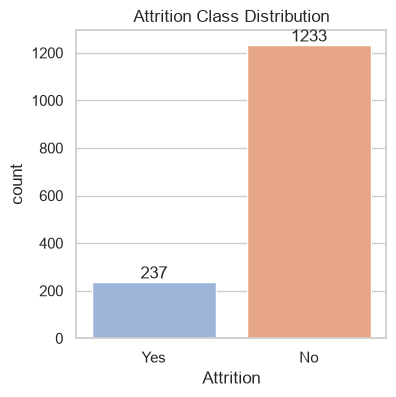

Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


In [9]:
attr_pct = df['Attrition'].value_counts(normalize=True) * 100

plt.figure(figsize=(4,4))
ax = sns.countplot(x='Attrition', data=df, palette=["#94B3E4","#F7A176"])
for c in ax.containers:
    ax.bar_label(c)
plt.title("Attrition Class Distribution")
plt.show()

print(attr_pct.round(1))


In [10]:
# checking for nulls
print("No of Nulls in each column:")
df.isna().sum()

No of Nulls in each column:


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [11]:
# check duplicates in dataset
print("Number of duplicates ", df.duplicated().sum())

Number of duplicates  0


In [12]:
print("unique values in column:")
df.nunique()

unique values in column:


Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [13]:
# drop Unnecessary columns
df = df.drop(columns=['EmployeeNumber','Over18','EmployeeCount','StandardHours'])

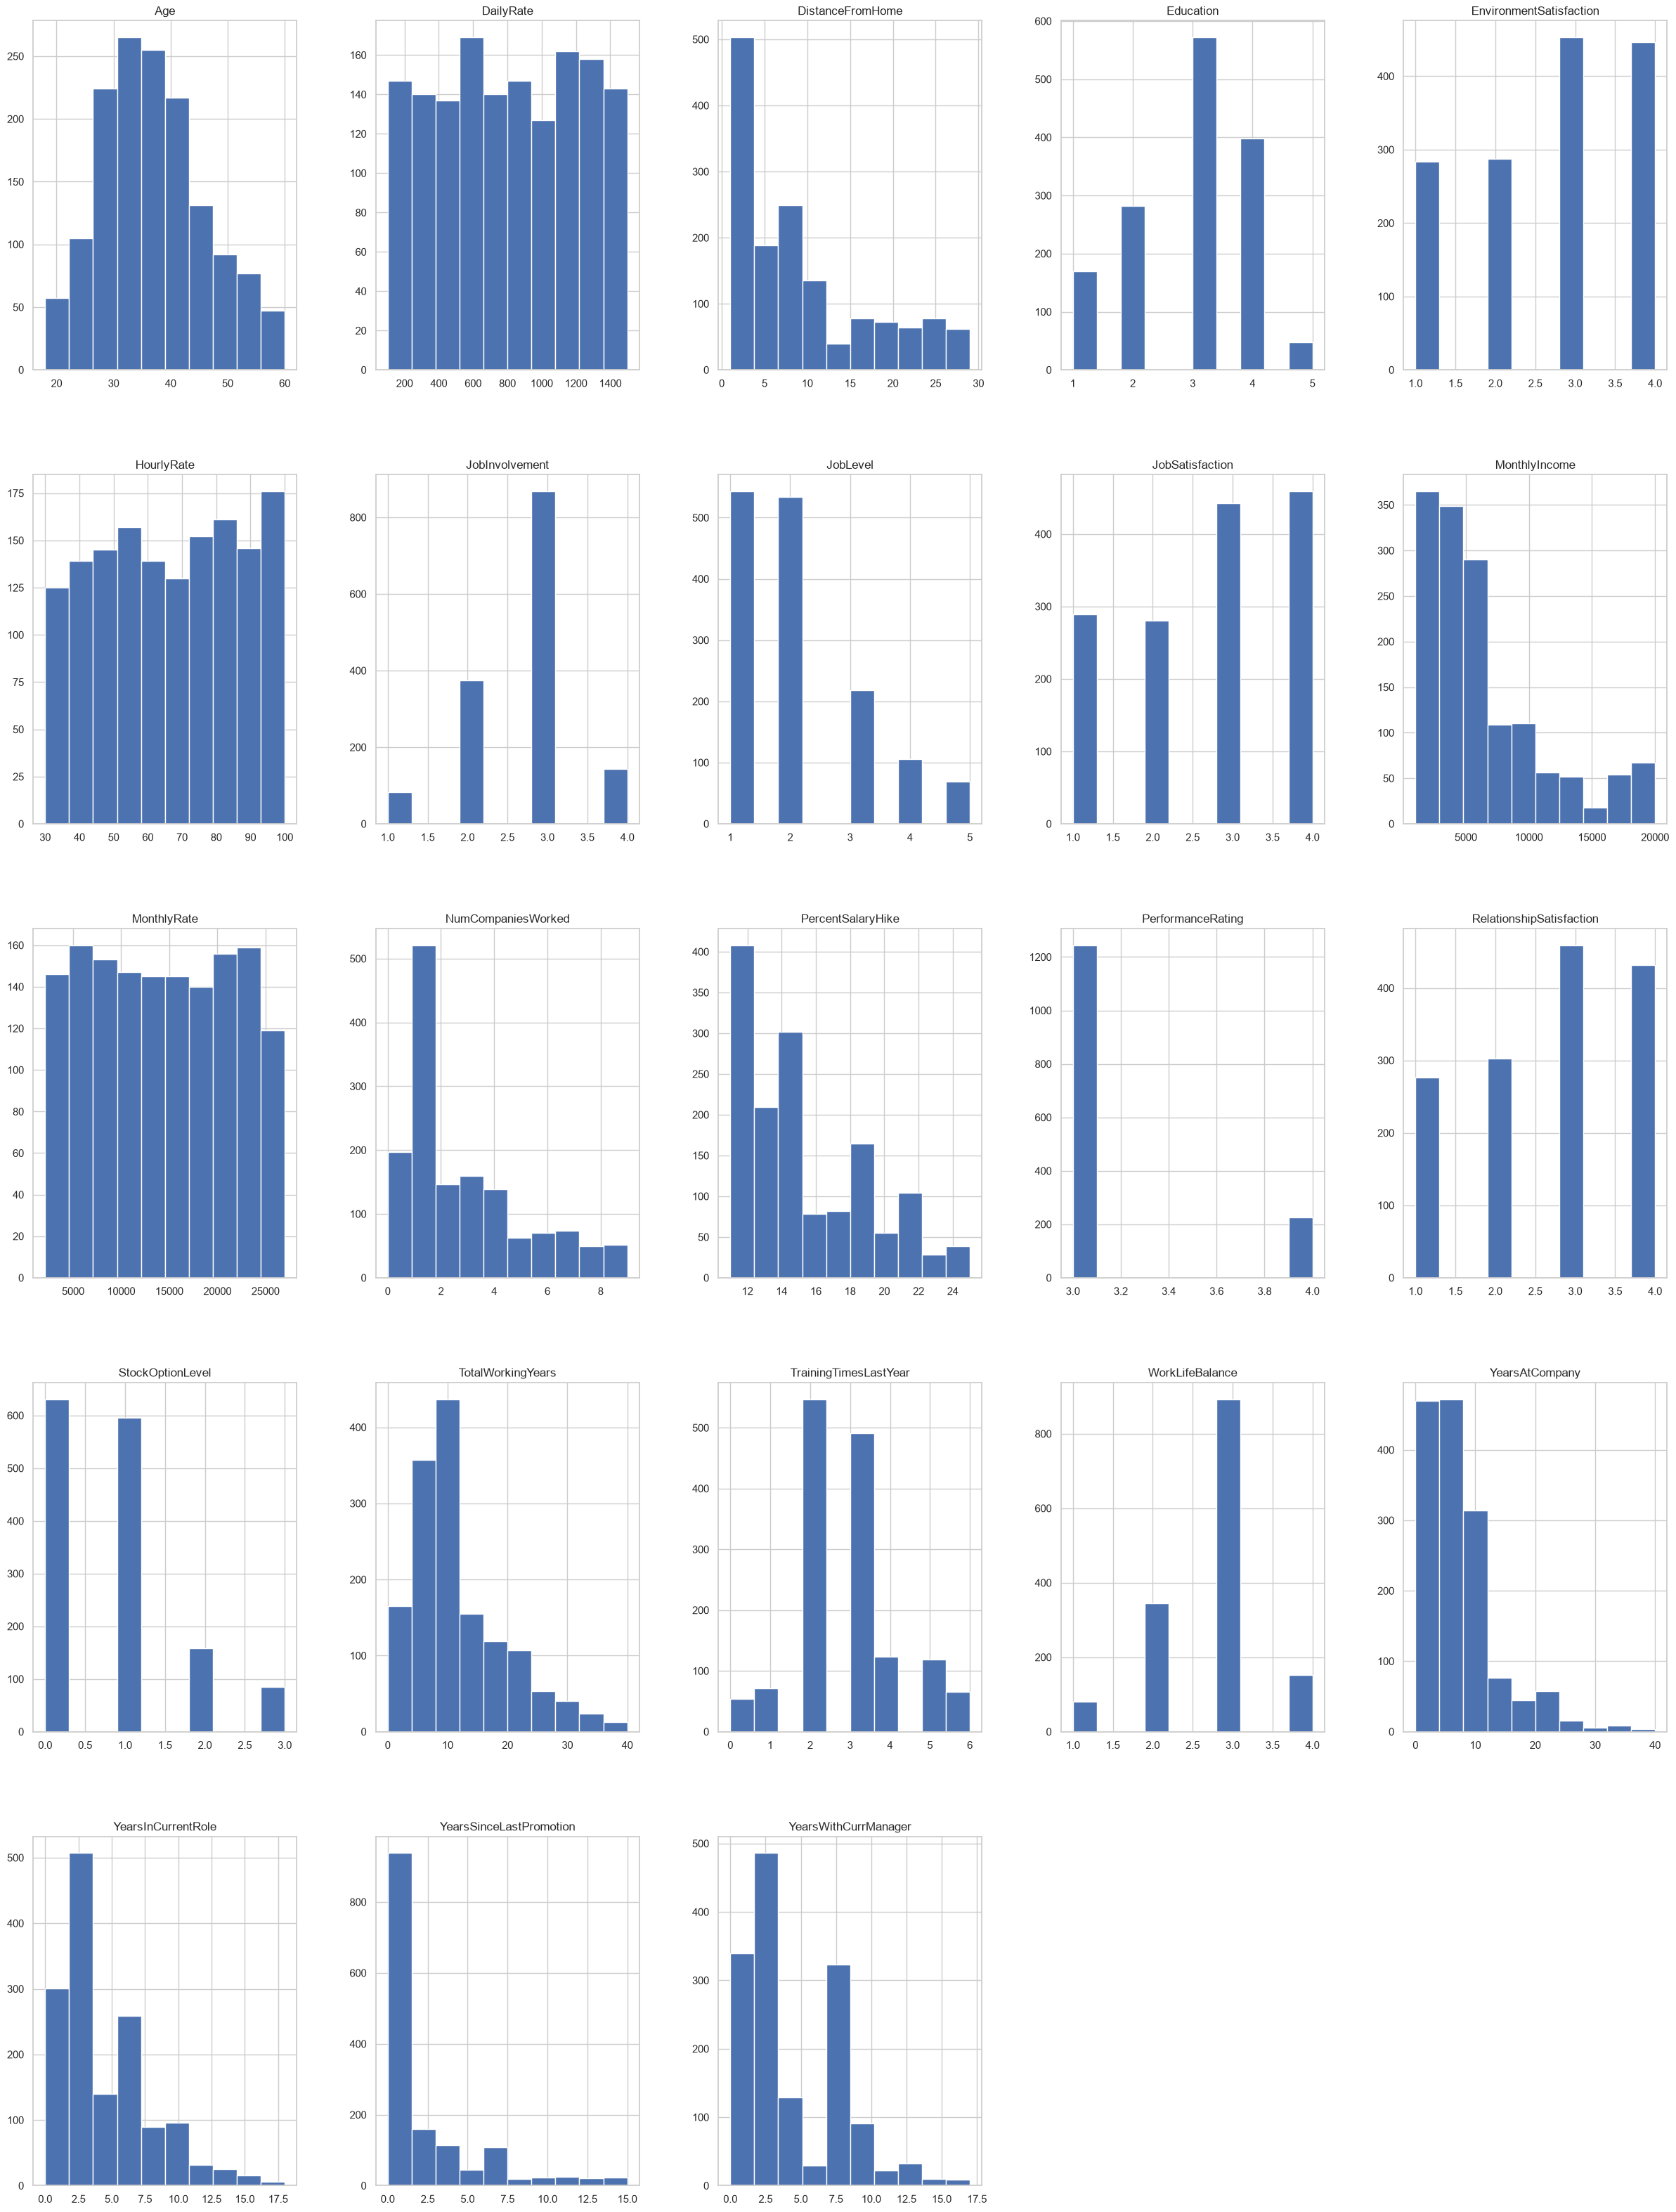

In [14]:
df.hist(figsize=(30,40))
plt.show()

#### Numerical Features vs Attrition


In [15]:
numerical_cols = df.select_dtypes(include='int64').columns
drop_cols = ['Age', 'DailyRate', 'HourlyRate','MonthlyRate','MonthlyIncome', "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "JobInvolvement",
    "WorkLifeBalance",
    "PerformanceRating",
    "StockOptionLevel"]

numerical_cols = numerical_cols.drop(drop_cols)


print(numerical_cols)

Index(['DistanceFromHome', 'Education', 'JobLevel', 'NumCompaniesWorked',
       'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')


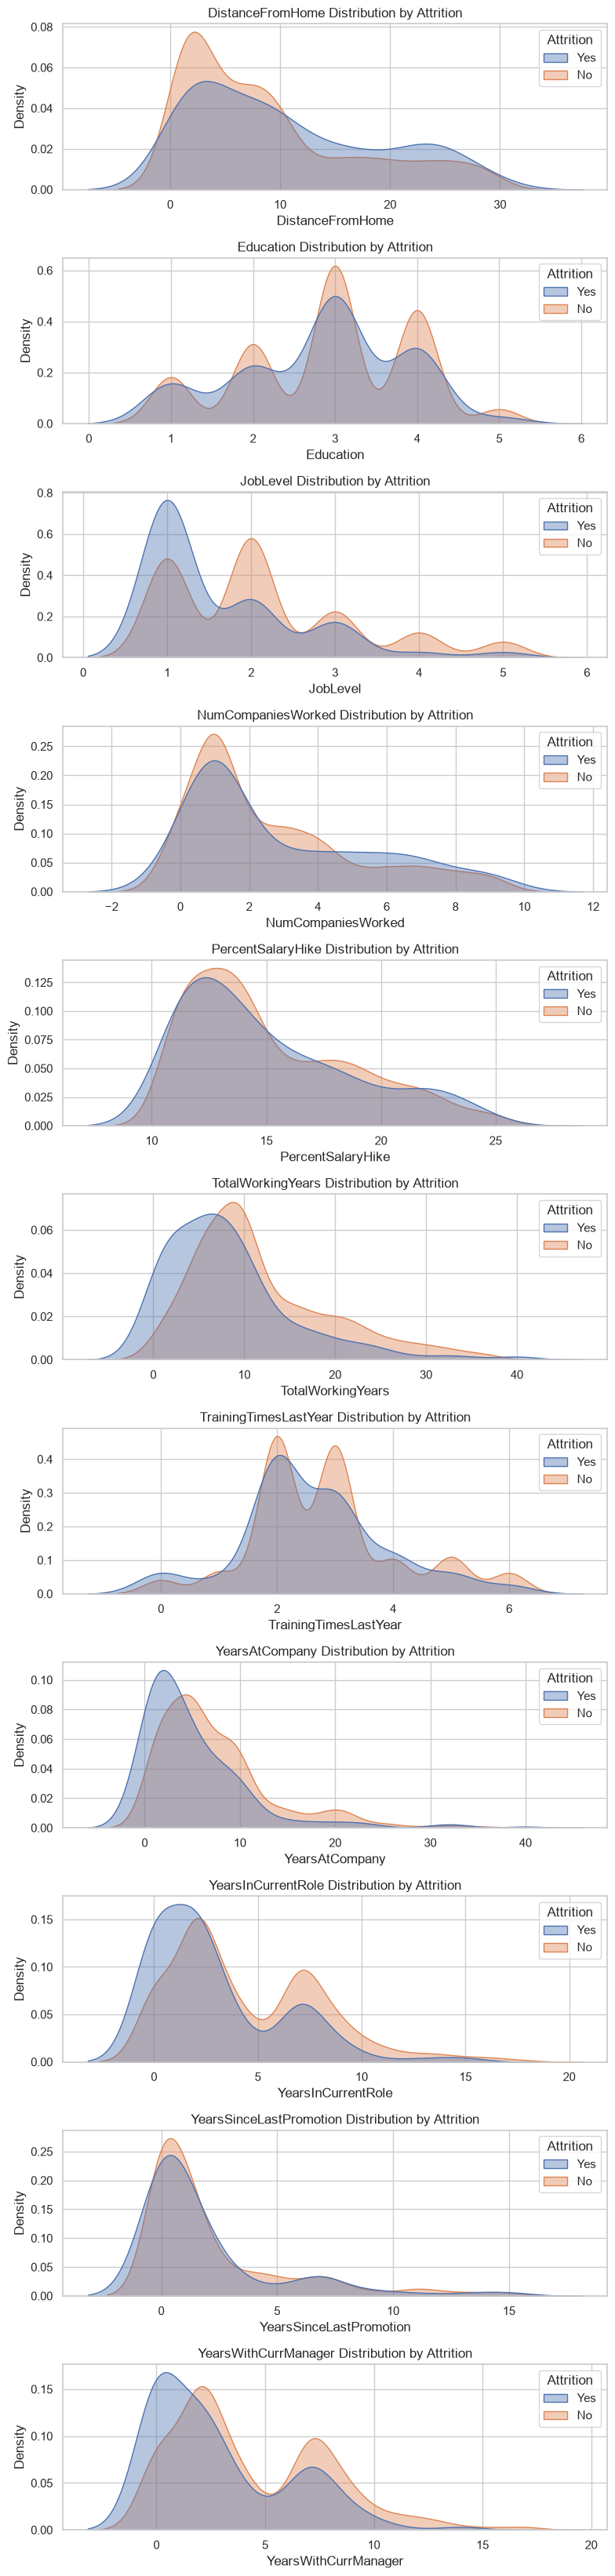

In [16]:
def plot_kde(df, numerical_cols):
    fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(8, 3*len(numerical_cols)))

    for ax, numerical_cols in zip(axes, numerical_cols):
        sns.kdeplot(
            data=df, x=numerical_cols, hue='Attrition',
            fill=True, alpha=0.4,
            common_norm=False,
            palette=['#4C72B0','#DD8452'],
            ax=ax
        )
        ax.set_title(f'{numerical_cols} Distribution by Attrition')

    plt.tight_layout()
    plt.show()

plot_kde(df, numerical_cols)

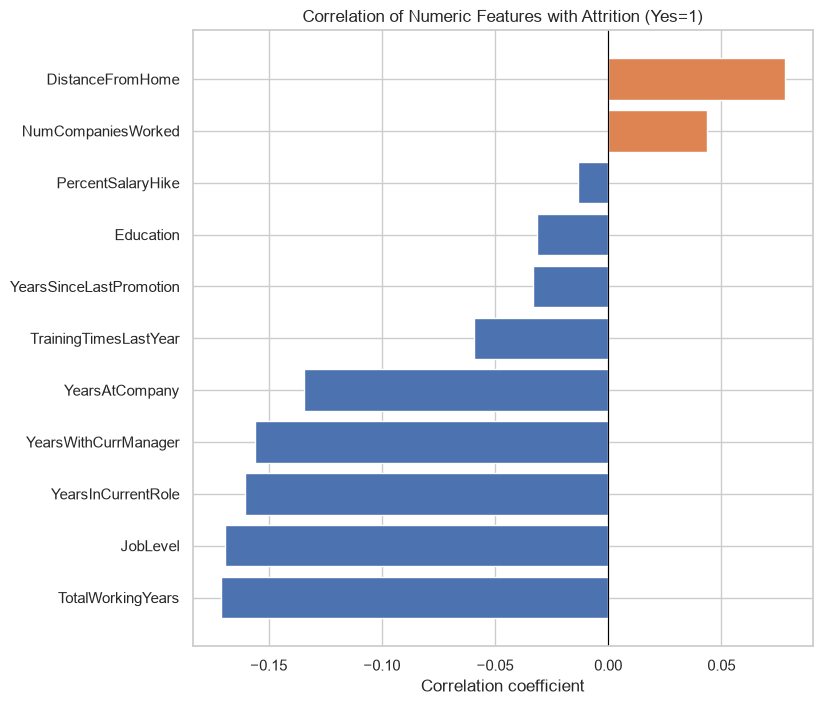

In [17]:
# Quick numeric summary of the plots above: correlation with the target
target_binary = (df['Attrition'] == 'Yes').astype(int)
corr_with_target = df[numerical_cols].apply(lambda x: x.corr(target_binary)).sort_values()

plt.figure(figsize=(8, 8))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr_with_target.values]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Numeric Features with Attrition (Yes=1)')
plt.xlabel('Correlation coefficient')
plt.show()

** Insights** `NumCompaniesWorked` and `DistanceFromHome` correlate mildly positively

#### Categorical Features vs Attrition


In [18]:
categorical_cols = df.select_dtypes(include='object').columns

categorical_cols=  categorical_cols.drop('Attrition')
print(categorical_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str')


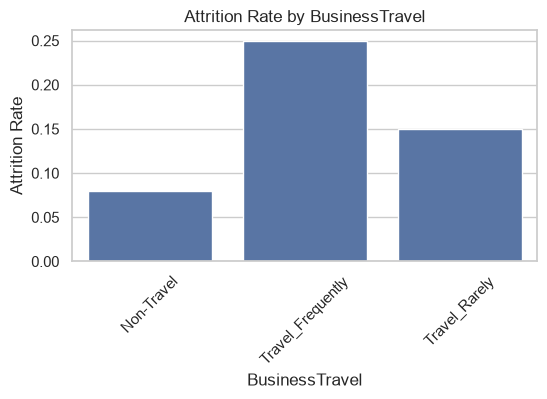

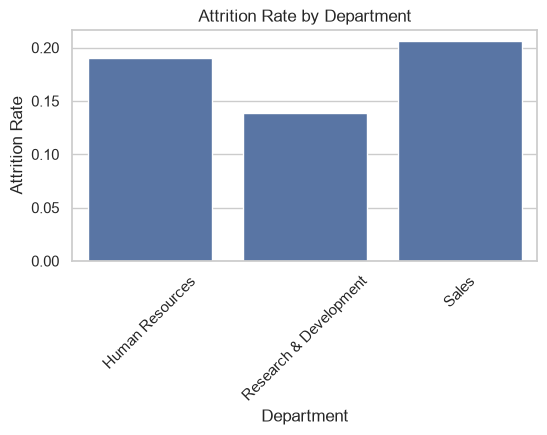

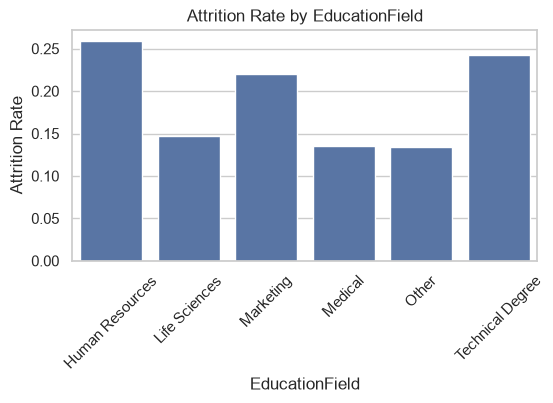

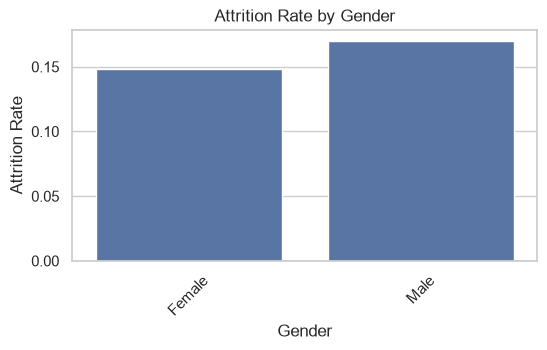

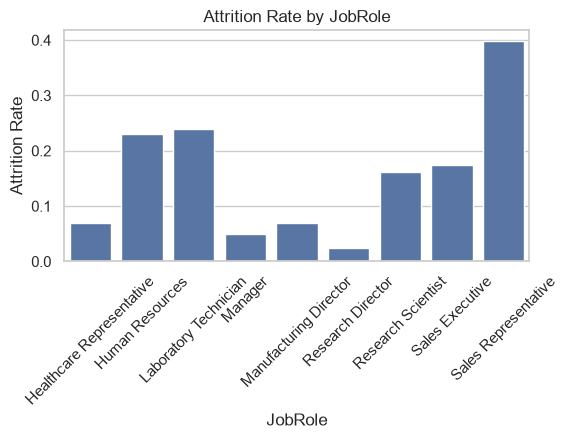

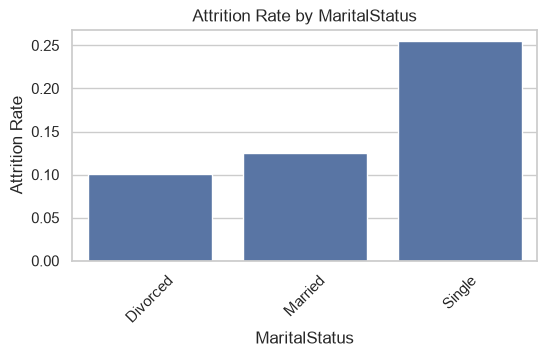

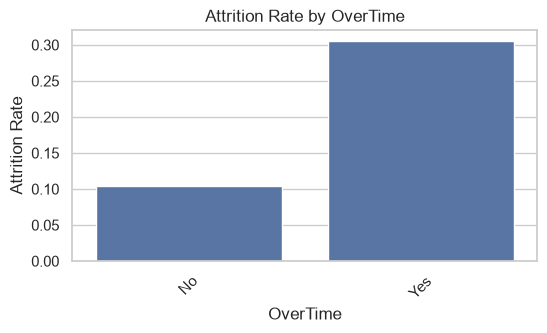

In [19]:
for col in categorical_cols:
    attrition_rate = (
        df.groupby(col)['Attrition']
        .value_counts(normalize=True)
        .rename('percentage')
        .reset_index()
    )

    yes_rate = attrition_rate[
        attrition_rate['Attrition'] == 'Yes'
    ]

    plt.figure(figsize=(6,3))
    sns.barplot(
        data=yes_rate,
        x=col,
        y='percentage',
        # palette= 'Set2'
    )

    plt.title(f'Attrition Rate by {col}')
    plt.ylabel('Attrition Rate')
    plt.xticks(rotation=45)
    plt.show()

**Insight:** `OverTime = Yes`, `BusinessTravel = Travel_Frequently`, `MaritalStatus = Single`, `EducationField = "Human Resources and Technical Degree` and `JobRole = Sales Representative` / `Laboratory Technician` show the highest attrition rates. `OverTime` stands out as one of the strongest predictors in the whole dataset.

#### Satisfaction & Involvement Features vs Attrition

In [20]:
satisfaction_features = [
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "JobInvolvement",
    "WorkLifeBalance",
    "PerformanceRating",
    "StockOptionLevel"
]
satisfaction_features

['JobSatisfaction',
 'EnvironmentSatisfaction',
 'RelationshipSatisfaction',
 'JobInvolvement',
 'WorkLifeBalance',
 'PerformanceRating',
 'StockOptionLevel']

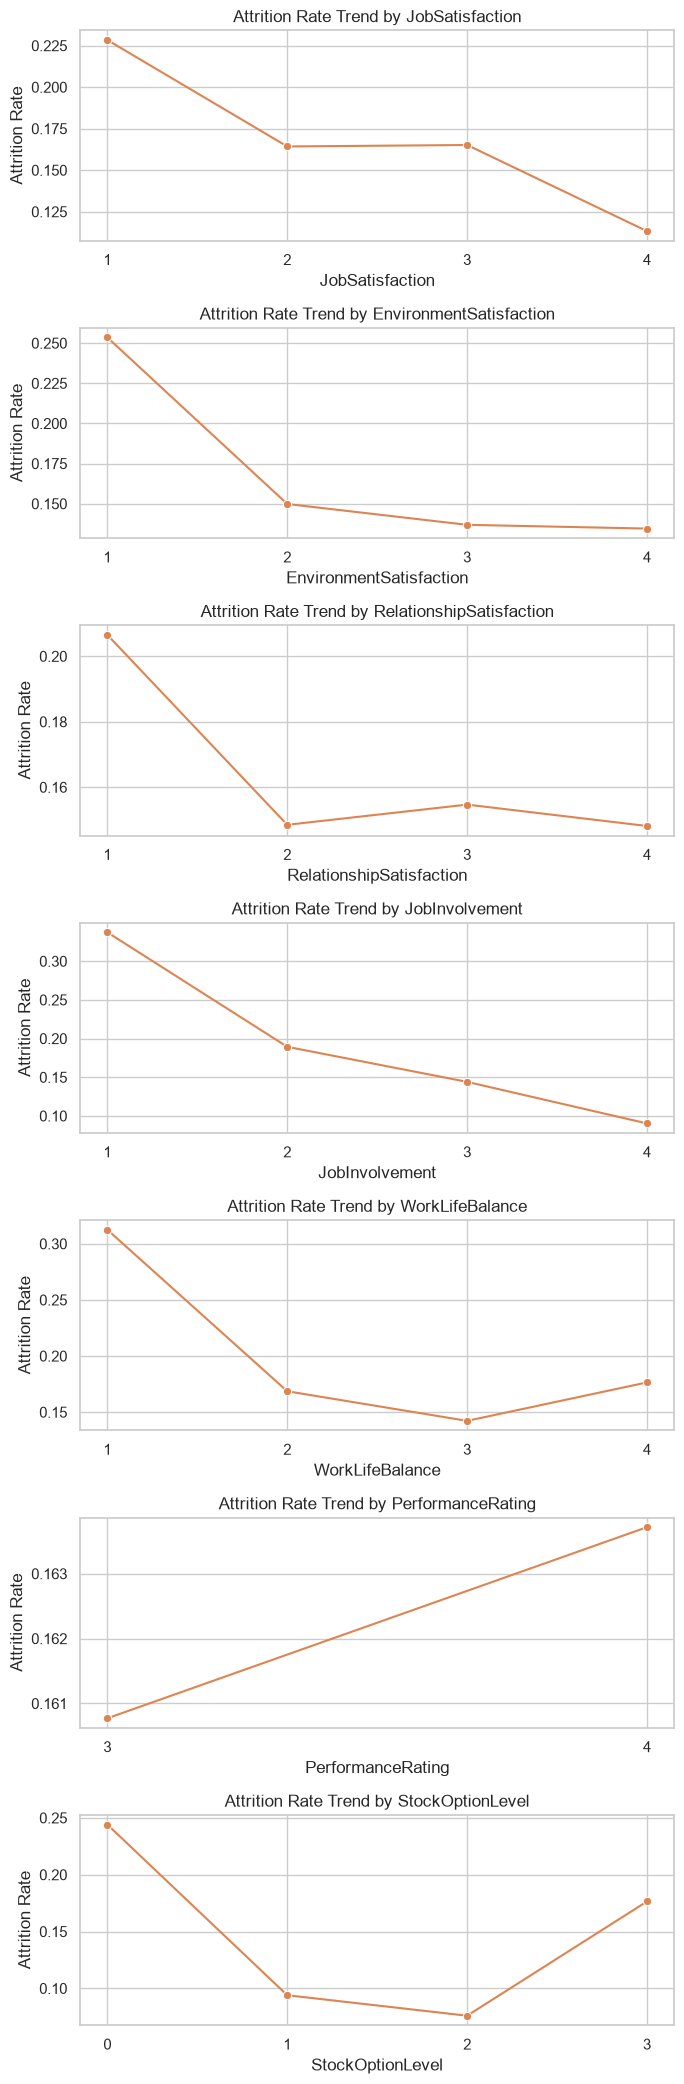

In [21]:
# Attrition rate trend across each satisfaction/involvement level (these are ordinal,
# so a line trend is more informative than a bar chart per category)
fig, axes = plt.subplots(len(satisfaction_features), 1, figsize=(7, 3*len(satisfaction_features)))

for ax, col in zip(axes, satisfaction_features):
    trend = (
        df.groupby(col)['Attrition']
        .apply(lambda s: (s == 'Yes').mean())
        .reset_index(name='AttritionRate')
    )
    sns.lineplot(data=trend, x=col, y='AttritionRate', marker='o', ax=ax, color='#DD8452')
    ax.set_title(f'Attrition Rate Trend by {col}')
    ax.set_ylabel('Attrition Rate')
    ax.set_xticks(sorted(df[col].unique()))

plt.tight_layout()
plt.show()

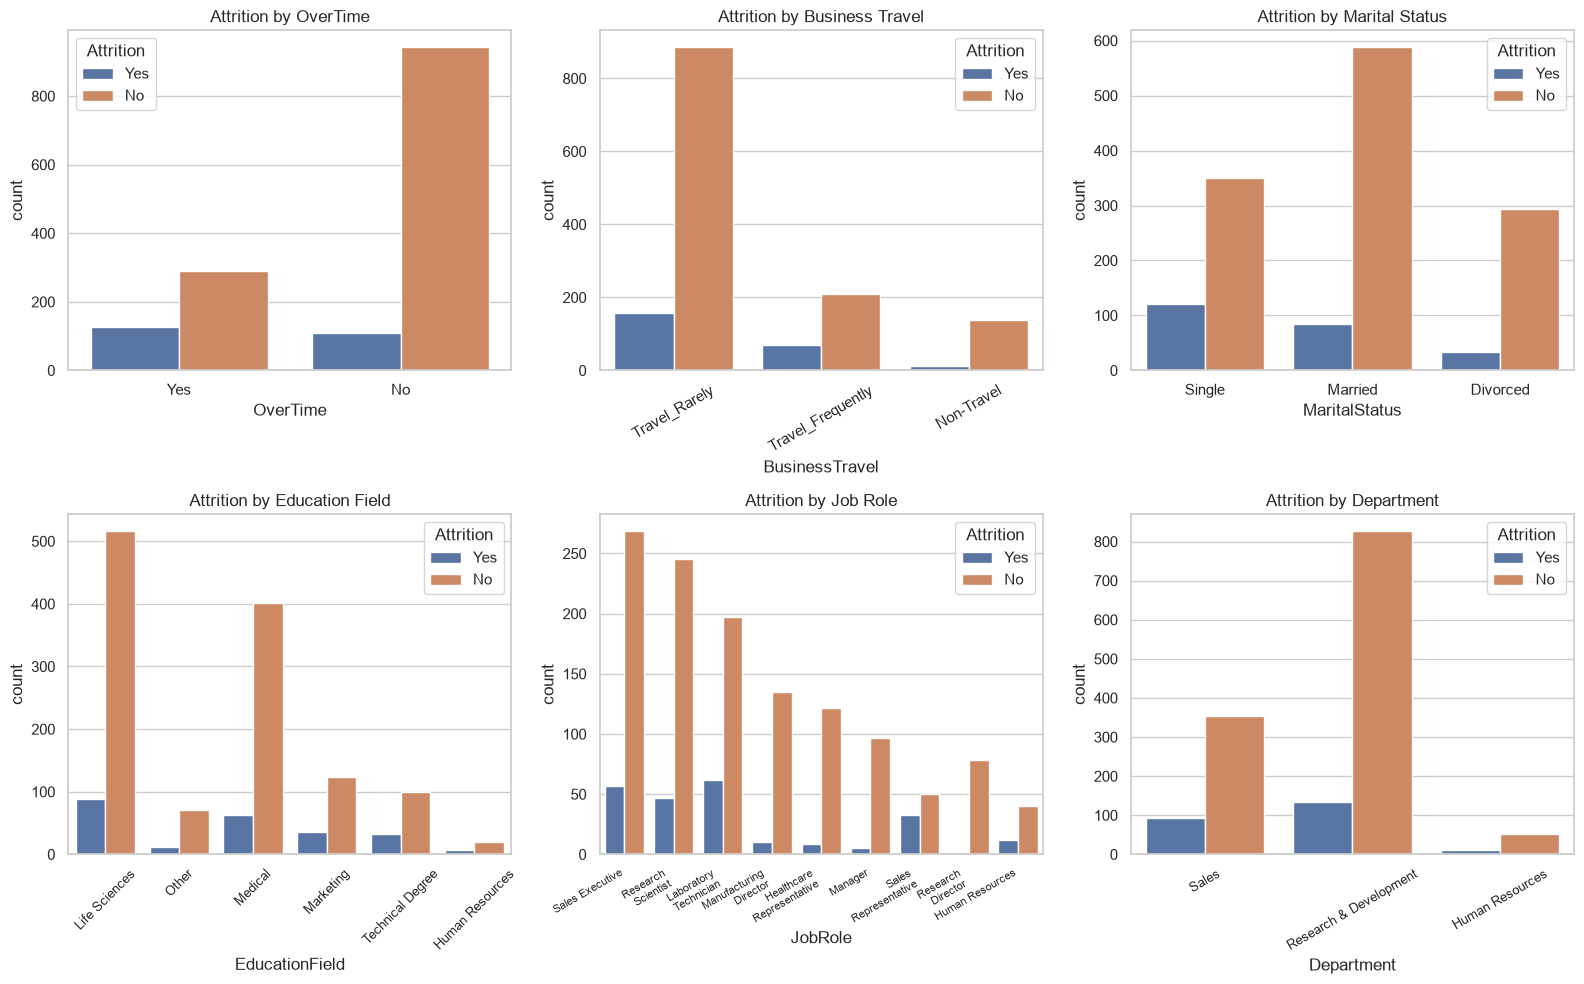

In [22]:
import textwrap
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. OverTime
sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[0, 0])
axes[0, 0].set_title('Attrition by OverTime')

# 2. BusinessTravel
sns.countplot(data=df, x='BusinessTravel', hue='Attrition', ax=axes[0, 1])
axes[0, 1].set_title('Attrition by Business Travel')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. MaritalStatus
sns.countplot(data=df, x='MaritalStatus', hue='Attrition', ax=axes[0, 2])
axes[0, 2].set_title('Attrition by Marital Status')

# 4. EducationField
sns.countplot(data=df, x='EducationField', hue='Attrition', ax=axes[1, 0])
axes[1, 0].set_title('Attrition by Education Field')
axes[1, 0].tick_params(axis='x', rotation=45, labelsize=9)

# 5. JobRole
sns.countplot(data=df, x='JobRole', hue='Attrition', ax=axes[1, 1])
axes[1, 1].set_title('Attrition by Job Role')

# 6. Department
sns.countplot(data=df, x='Department', hue='Attrition', ax=axes[1, 2])
axes[1, 2].set_title('Attrition by Department')
axes[1, 2].tick_params(axis='x', rotation=30, labelsize=9)

job_labels = [
    '\n'.join(textwrap.wrap(str(label.get_text()), 15))
    for label in axes[1, 1].get_xticklabels()
]
axes[1, 1].set_xticklabels(job_labels, rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('categorical_risk_factors.png', dpi=300, bbox_inches='tight')
plt.show()

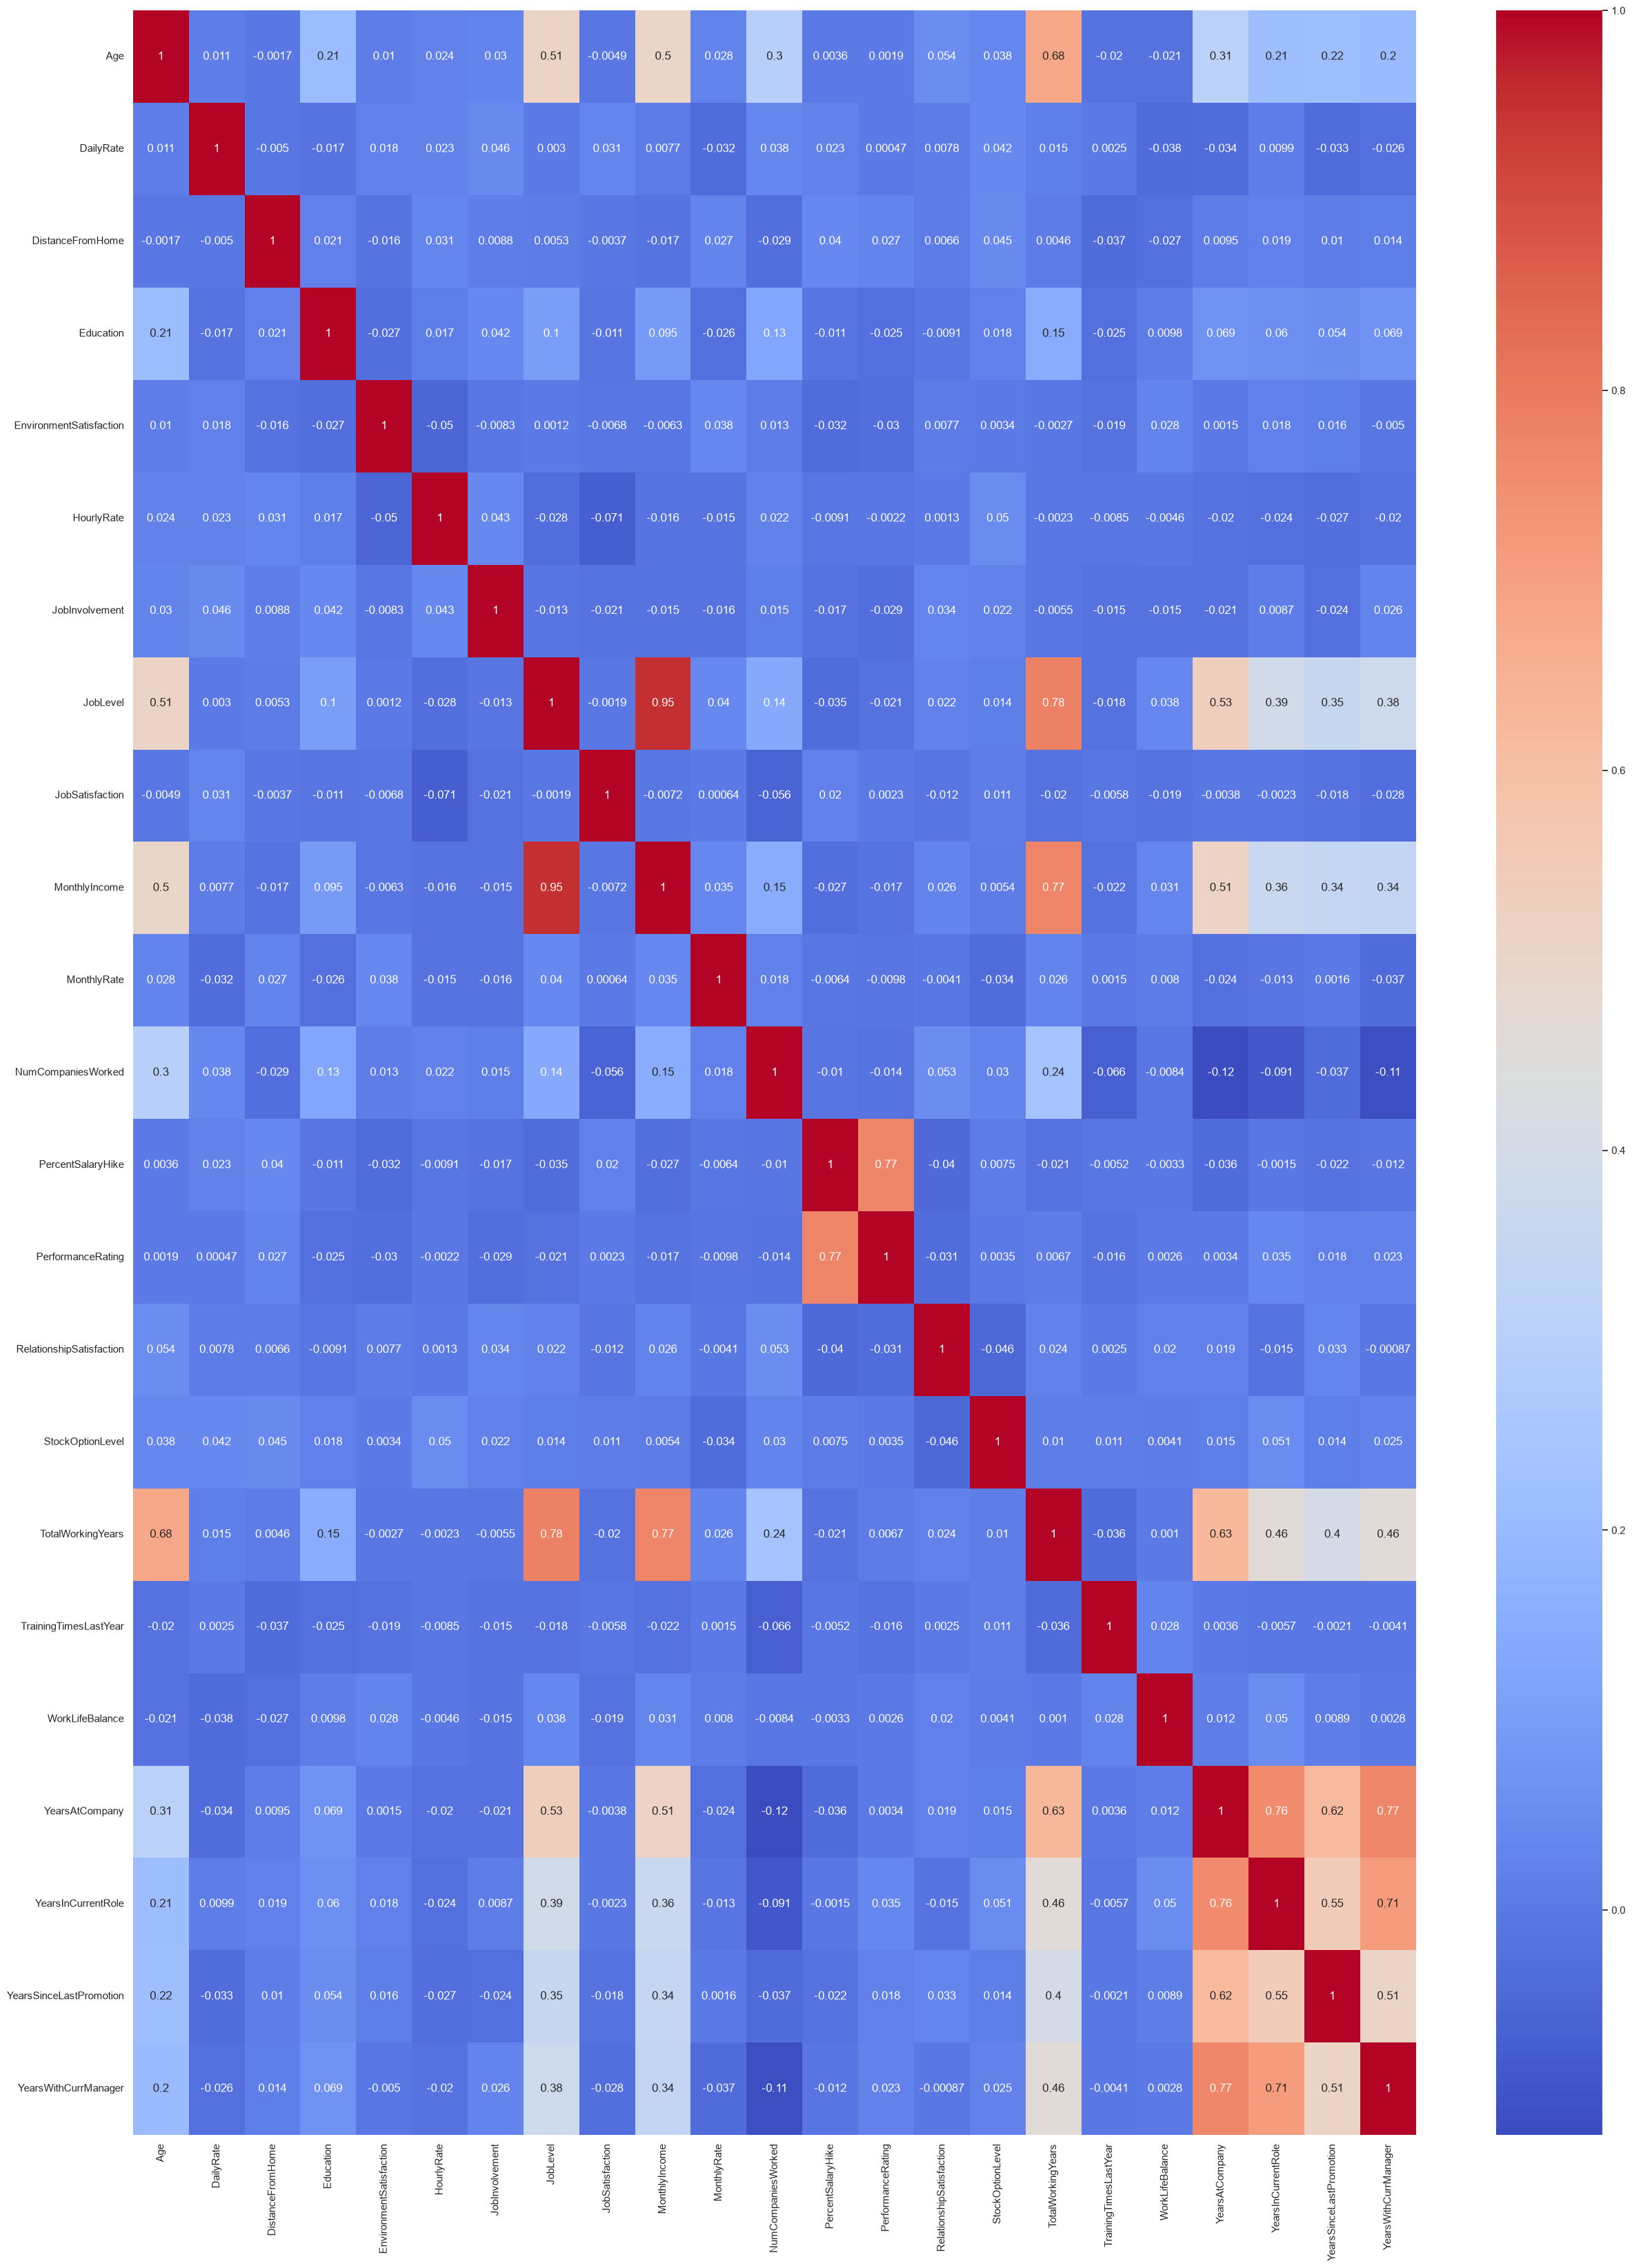

In [23]:
plt.figure(figsize=(30,40))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

### 2. Data Cleaning

In [24]:
print("Total missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Total missing values: 0
Duplicate rows: 0


##### 2.1 Outlier Treatment

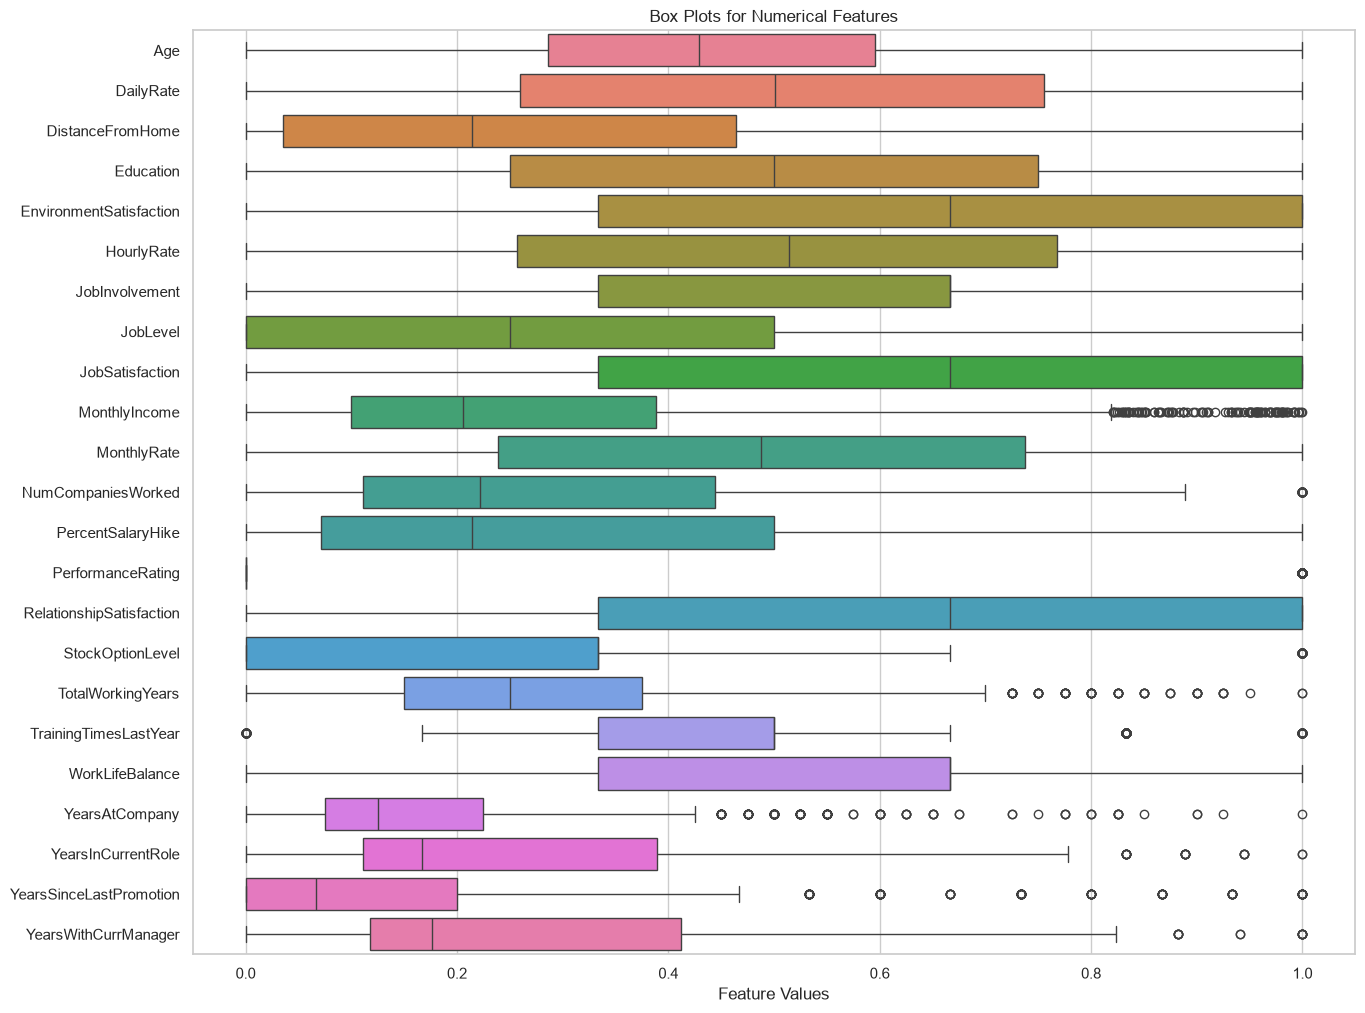

In [25]:
# checking outlier in numerical columns

numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()


data_for_boxplot = df[numerical_columns]

# MinMax scaling on numerical columns for better box plot interpretation
scaler = MinMaxScaler()
data_for_boxplot[numerical_columns] = scaler.fit_transform(data_for_boxplot[numerical_columns])

# Set the style of the visualization
sns.set(style="whitegrid", palette="pastel")

# Plot box plots for all numerical features
plt.figure(figsize=(15, 12))
sns.boxplot(data=data_for_boxplot, orient="h")
plt.title("Box Plots for Numerical Features")
plt.xlabel("Feature Values")
plt.show()

In [26]:
# outlier treatment 
numerical_cols = ['MonthlyIncome','NumCompaniesWorked','TotalWorkingYears', 'PerformanceRating','StockOptionLevel','TrainingTimesLastYear','YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager']

# Remove outliers using IQR
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))

print(df.shape)

(1470, 31)


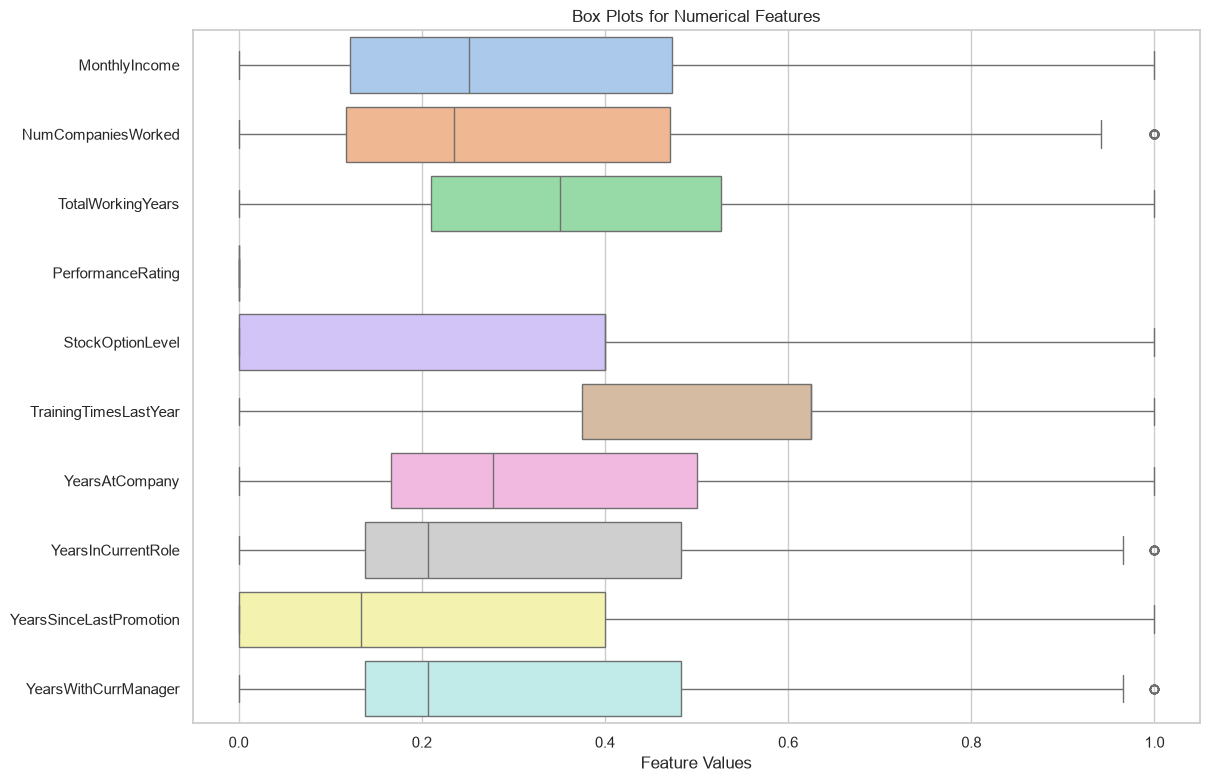

In [27]:
# checking columns after outlier treatment using boxplot
numerical_columns = ['MonthlyIncome','NumCompaniesWorked','TotalWorkingYears', 'PerformanceRating','StockOptionLevel','TrainingTimesLastYear','YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager']

# numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

data_for_boxplot = df[numerical_columns]

# MinMax scaling on numerical columns for better box plot interpretation
scaler = MinMaxScaler()
data_for_boxplot[numerical_columns] = scaler.fit_transform(data_for_boxplot[numerical_columns])

# Set the style of the visualization
sns.set(style="whitegrid", palette="pastel")

# Plot box plots for all numerical features
plt.figure(figsize=(13, 9))
sns.boxplot(data=data_for_boxplot, orient="h")
plt.title("Box Plots for Numerical Features")
plt.xlabel("Feature Values")
plt.show()

In [28]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [29]:
X.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,3.0,1,0.0,8.0,0.5,1,6.0,4.0,0.0,5.0
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,...,3.0,4,1.0,10.0,3.0,3,10.0,7.0,1.0,7.0
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,...,3.0,2,0.0,7.0,3.0,3,0.0,0.0,0.0,0.0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,...,3.0,3,0.0,8.0,3.0,3,8.0,7.0,3.0,0.0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,...,3.0,4,1.0,6.0,3.0,3,2.0,2.0,2.0,2.0


In [30]:
y.head()

0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: str

### 3. Data Preprocessing

In [31]:
#### Converting Categorical column to Numerical using OneHotEncoder


categorical_cols = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

X_encoded = preprocessor.fit_transform(X)

In [32]:
X_encoded

array([[0., 1., 0., ..., 4., 0., 5.],
       [1., 0., 1., ..., 7., 1., 7.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 2., 0., 3.],
       [1., 0., 0., ..., 6., 0., 8.],
       [0., 1., 1., ..., 3., 1., 2.]], shape=(1470, 44))

In [33]:
#coverting target values to numerical using LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [34]:
y

array([1, 0, 1, ..., 0, 0, 0], shape=(1470,))

In [35]:
# splitting data to train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (1176, 44)  Test: (294, 44)


In [36]:
##running LR model without smote to check model performance on Imbalanced dataset
X_train_copy = X_train.copy()
X_test_copy = X_test.copy()


scaler = StandardScaler()
X_train_copy = scaler.fit_transform(X_train_copy)
X_test_copy = scaler.transform(X_test_copy)

model = LogisticRegression()
model.fit(X_train_copy, y_train)
y_pred = model.predict(X_test_copy)
y_pred_train = model.predict(X_train_copy) 

print("Train_Accuracy :", accuracy_score(y_train, y_pred_train))
print("Test_Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Train_Accuracy : 0.9022108843537415
Test_Accuracy : 0.8639455782312925
Precision: 0.6296296296296297
Recall   : 0.3617021276595745
F1 Score : 0.4594594594594595


#### SMOTE for class imbalance

In [37]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [38]:
print("\n Training class distribution:\n", pd.Series(y_train).value_counts())



 Training class distribution:
 0    986
1    190
Name: count, dtype: int64


### 4. Model Implementation


#### Model 1 : Logistic Regression(baseline)

##### 1.1 LR Model without Hypertuning

In [39]:
# Create a logistic regression model
model = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression())
])

# Train the model on the training data
model.fit(X_train, y_train)


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
n_features_in_,int,44
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [40]:
# predict y_pred on test data
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train) 

In [41]:
# Evalution Metrics

accuracy_LR_train = accuracy_score(y_train, y_pred_train)
print("Training Accuracy", accuracy_LR_train)

accuracy_LR = accuracy_score(y_test, y_pred)
print("Accuracy :\t",accuracy_LR)

Diff_in_accuracy_LR = accuracy_LR_train - accuracy_LR
print("Diff_in_accuracy_LR :\t",Diff_in_accuracy_LR)

precision_LR = precision_score(y_test, y_pred)
print("Precision :\t",precision_LR)


recall_LR = recall_score(y_test, y_pred)
print("Recall :\t",recall_LR)


f1_LR = f1_score(y_test, y_pred)
print("F1-Score :\t",f1_LR)


fpr_LR, tpr_LR, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
auc_LR = roc_auc_score(y_test, y_pred)
print("AUC :\t\t",auc_LR)


conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix :\t",conf_matrix)

Training Accuracy 0.8027210884353742
Accuracy :	 0.7721088435374149
Diff_in_accuracy_LR :	 0.030612244897959218
Precision :	 0.375
Recall :	 0.6382978723404256
F1-Score :	 0.47244094488188976
AUC :		 0.7179343612714273
Confusion Matrix :	 [[197  50]
 [ 17  30]]


##### 1.2 LR Model Hypertuning

In [42]:


lr = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        solver='liblinear',   # Supports both L1 and L2
        max_iter=1000,
        random_state=42
    ))
])

param_grid = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100]
}

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Recall:", grid.best_score_)

best_lr_model = grid.best_estimator_
best_model = best_lr_model

y_pred = best_lr_model.predict(X_test)

print(classification_report(y_test, y_pred))

Best Parameters: {'model__C': 0.001, 'model__penalty': 'l2'}
Best CV Recall: 0.8052631578947368
              precision    recall  f1-score   support

           0       0.94      0.58      0.72       247
           1       0.26      0.79      0.40        47

    accuracy                           0.62       294
   macro avg       0.60      0.69      0.56       294
weighted avg       0.83      0.62      0.67       294



##### 1.3 Final Metrics using model with best parameters

prediction using best Logistic regression model:-

Training Metrics
----------------
Accuracy: 0.6445578231292517
Recall: 0.8210526315789474
F1: 0.4273972602739726

Testing Metrics
----------------
Accuracy: 0.6156462585034014
Recall: 0.7872340425531915
F1: 0.39572192513368987
AUC: 0.6851149969850977
Confusion Matrix: [[144 103]
 [ 10  37]]


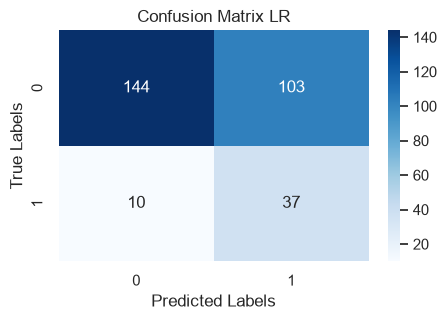

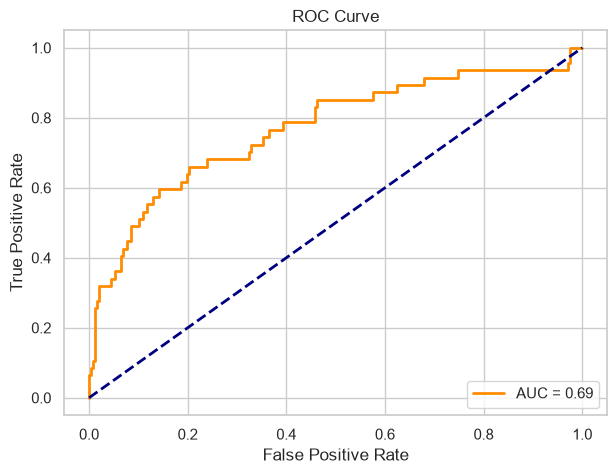

In [93]:
## prediction using best Logistic regression model--
print("prediction using best Logistic regression model:-")
print()
# Training prediction
train_pred = best_lr_model.predict(X_train)

# Test prediction
test_pred = best_lr_model.predict(X_test)


print("Training Metrics")
print("----------------")
Train_Accuracy_LR = accuracy_score(y_train, train_pred)
print("Accuracy:", accuracy_score(y_train, train_pred))
print("Recall:", recall_score(y_train, train_pred))
print("F1:", f1_score(y_train, train_pred))


print()
print("Testing Metrics")
print("----------------")
Accuracy_LR = accuracy_score(y_test, test_pred)
Precision_LR = precision_score(y_test, test_pred)
Recall_LR = recall_score(y_test, test_pred)
F1_score_LR = f1_score(y_test, test_pred)
fpr_LR, tpr_LR, thresholds = roc_curve(y_test, best_lr_model.predict_proba(X_test)[:, 1])
AUC_LR = roc_auc_score(y_test, test_pred)
Conf_Matrix_LR = confusion_matrix(y_test, test_pred)

print("Accuracy:", Accuracy_LR)
print("Recall:", Recall_LR)
print("F1:", F1_score_LR)
print("AUC:",AUC_LR)
print("Confusion Matrix:",Conf_Matrix_LR)

# Visualization of Confusion Matrix
plt.figure(figsize=(5, 3))
sns.heatmap(Conf_Matrix_LR, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix LR')
plt.show()

# Visualization of ROC AUC Curve

plt.figure(figsize=(7, 5))
plt.plot(fpr_LR, tpr_LR, color='darkorange', lw=2, label=f'AUC = {AUC_LR:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [94]:
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(best_lr_model.named_steps['scaler'].transform(X_train), columns=feature_names)


#### Model 2. Random Forest

##### 2.1 Model without hyper-parameters

In [45]:



RFModel = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier( random_state=42,n_jobs=-1))
])
RFModel.fit(X_train, y_train)

y_pred_RF = RFModel.predict(X_test)

y_pred_train_RF = RFModel.predict(X_train)

# Evaluation Metrics
print("\nEvaluation Metrics:")

accuracy_train_RF = accuracy_score(y_train, y_pred_train_RF)
print("Training Accuracy :\t", accuracy_train_RF)

accuracy_RF = accuracy_score(y_test, y_pred_RF)
print("Accuracy :\t",accuracy_RF)


precision_RF = precision_score(y_test, y_pred_RF)
print("Precision :\t",precision_RF)


recall_RF = recall_score(y_test, y_pred_RF)
print("Recall :\t",recall_RF)

f1_RF = f1_score(y_test, y_pred_RF)
print("F1-Score :\t",f1_RF)

fpr, tpr, thresholds = roc_curve(y_test, RFModel.predict_proba(X_test)[:, 1])
auc_RF = roc_auc_score(y_test, y_pred_RF)
print("AUC :\t\t",auc_RF)

conf_matrix_RF = confusion_matrix(y_test, y_pred_RF)
print("Confusion Matrix :\t",conf_matrix_RF)


Evaluation Metrics:
Training Accuracy :	 1.0
Accuracy :	 0.8571428571428571
Precision :	 0.6666666666666666
Recall :	 0.2127659574468085
F1-Score :	 0.3225806451612903
AUC :		 0.5962615212335258
Confusion Matrix :	 [[242   5]
 [ 37  10]]


##### 2.2 Finding Best hypermparameters

In [47]:


rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ))
])

param_grid = {
    'model__n_estimators': [100,150,200,250,300,350,400],
    'model__max_depth': [3,5,7,10,None],
    'model__min_samples_leaf': [2,3,5,10],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2']
  
  
}


grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)


grid_rf.fit(X_train, y_train)


best_rf = grid_rf.best_estimator_


print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV Recall:")
print(grid_rf.best_score_)

Fitting 5 folds for each of 840 candidates, totalling 4200 fits
Best Parameters:
{'model__max_depth': 3, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 350}

Best CV Recall:
0.4789473684210527


##### 2.3 Final Metrics using model with best parameters

prediction using best Random Forest model:-

Training Metrics
----------------
Accuracy: 0.8698979591836735
Recall: 0.5157894736842106
F1: 0.5616045845272206

Testing Metrics
----------------
Accuracy: 0.8231292517006803
Recall: 0.425531914893617
F1: 0.43478260869565216
AUC: 0.6621586699974158
Confusion Matrix: [[222  25]
 [ 27  20]]


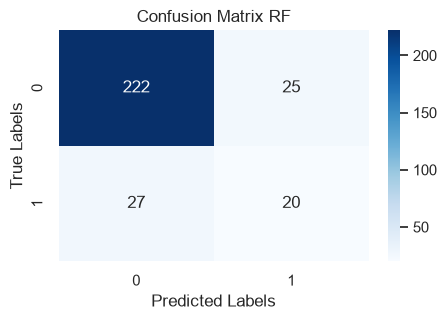

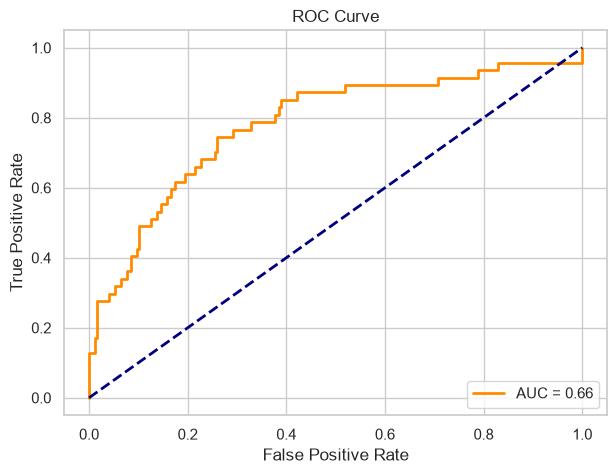

In [48]:
## prediction using best Logistic regression model--
print("prediction using best Random Forest model:-\n")

# Training prediction
train_pred = best_rf.predict(X_train)

# Test prediction
test_pred = best_rf.predict(X_test)


print("Training Metrics")
print("----------------")
print("Accuracy:", accuracy_score(y_train, train_pred))
print("Recall:", recall_score(y_train, train_pred))
print("F1:", f1_score(y_train, train_pred))


print("\nTesting Metrics")
print("----------------")
Accuracy_RF = accuracy_score(y_test, test_pred)
Recall_RF = recall_score(y_test, test_pred)
F1_score_RF = f1_score(y_test, test_pred)
fpr_RF, tpr_RF, thresholds = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
AUC_RF = roc_auc_score(y_test, test_pred)
Conf_Matrix_RF = confusion_matrix(y_test, test_pred)

print("Accuracy:", Accuracy_RF)
print("Recall:", Recall_RF)
print("F1:", F1_score_RF)
print("AUC:",AUC_RF)
print("Confusion Matrix:",Conf_Matrix_RF)

# Visualization of Confusion Matrix
plt.figure(figsize=(5, 3))
sns.heatmap(Conf_Matrix_RF, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix RF')
plt.show()

# Visualization of ROC AUC Curve

plt.figure(figsize=(7, 5))
plt.plot(fpr_RF, tpr_RF, color='darkorange', lw=2, label=f'AUC = {AUC_RF:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()



In [49]:
# ---- Capturing additional metrics for Random Forest (best_rf) for model comparison later ----
Train_Accuracy_RF = accuracy_score(y_train, best_rf.predict(X_train))
Precision_RF = precision_score(y_test, best_rf.predict(X_test))

print("Train Accuracy (RF):", Train_Accuracy_RF)
print("Precision (RF)     :", Precision_RF)


Train Accuracy (RF): 0.8698979591836735
Precision (RF)     : 0.4444444444444444


#### Model 3. XGBoost

In [50]:


xgb_model_full = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        n_jobs=1
    ))
])

param_grid_xgb_full = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [1, 2, 3, 4],
    # 'model__subsample': [0.8, 1.0],
    # 'model__colsample_bytree': [0.8, 1.0]
}

grid_xgb_full = GridSearchCV(
    estimator=xgb_model_full,
    param_grid=param_grid_xgb_full,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_xgb_full.fit(X_train, y_train)

print("Best Parameters:", grid_xgb_full.best_params_)
print("Best CV Recall  :", grid_xgb_full.best_score_)

best_xgb_full = grid_xgb_full.best_estimator_

Best Parameters: {'model__learning_rate': 0.01, 'model__max_depth': 1, 'model__n_estimators': 400}
Best CV Recall  : 0.5368421052631579


In [52]:
y_pred_xgb_full = best_xgb_full.predict(X_test)

print(classification_report(y_test, y_pred_xgb_full))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       247
           1       0.52      0.55      0.54        47

    accuracy                           0.85       294
   macro avg       0.72      0.73      0.72       294
weighted avg       0.85      0.85      0.85       294



Accuracy :	 0.8469387755102041
Precision :	 0.52
Recall :	 0.5531914893617021
F1-Score :	 0.5360824742268041
Confusion Matrix :	 [[223  24]
 [ 21  26]]


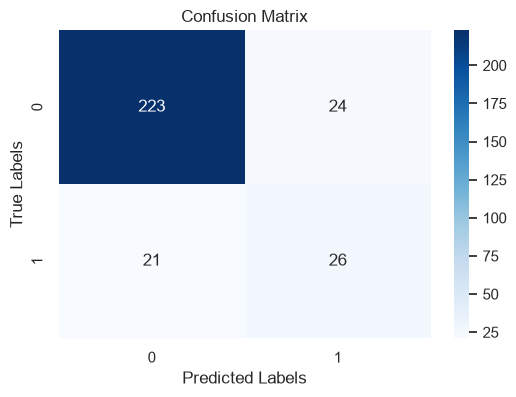

In [53]:
accuracy = accuracy_score(y_test, y_pred_xgb_full)
print("Accuracy :	",accuracy)

precision = precision_score(y_test, y_pred_xgb_full)
print("Precision :	",precision)

recall = recall_score(y_test, y_pred_xgb_full)
print("Recall :	",recall)

f1 = f1_score(y_test, y_pred_xgb_full)
print("F1-Score :	",f1)

conf_matrix = confusion_matrix(y_test, y_pred_xgb_full)
print("Confusion Matrix :	",conf_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [54]:
# ---- Capturing XGBoost (tuned, full-feature) metrics for model comparison later ----
Accuracy_XGB_full = accuracy
Precision_XGB_full = precision
Recall_XGB_full = recall
F1_score_XGB_full = f1
Conf_Matrix_XGB_full = conf_matrix

print("Test Accuracy (XGB Full) :", Accuracy_XGB_full)
print("Precision (XGB Full)     :", Precision_XGB_full)
print("Recall (XGB Full)        :", Recall_XGB_full)
print("F1 (XGB Full)             :", F1_score_XGB_full)

Test Accuracy (XGB Full) : 0.8469387755102041
Precision (XGB Full)     : 0.52
Recall (XGB Full)        : 0.5531914893617021
F1 (XGB Full)             : 0.5360824742268041


##### 4.1 XGBoost Feature Importance
1. Analyze and Extract Feature Importance

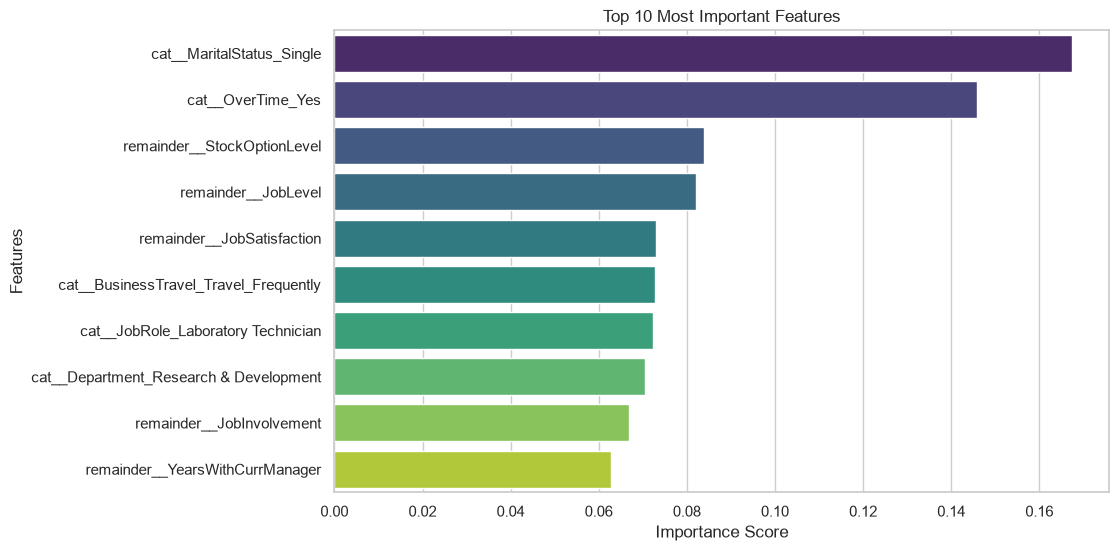

,Feature,Importance
19,cat__MaritalStatus_Single,0.167521
20,cat__OverTime_Yes,0.145858
36,remainder__StockOptionLevel,0.083998
28,remainder__JobLevel,0.081966
29,remainder__JobSatisfaction,0.073045
0,cat__BusinessTravel_Travel_Frequently,0.072779
11,cat__JobRole_Laboratory Technician,0.072406
2,cat__Department_Research & Development,0.070583
27,remainder__JobInvolvement,0.066781
43,remainder__YearsWithCurrManager,0.062700


In [56]:
from xgboost import plot_importance

feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train, columns=feature_names)
importances = best_xgb_full.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

top_features = feature_importance_df.head(10)['Feature'].values
X_train_reduced = X_train_df[top_features]

X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_test_reduced = X_test_df[top_features]

top_10_df = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_df, palette='viridis')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

top_10_df

2. Refine iterations, learning rate, and depth for reduced XGBoost model

In [57]:
xgb_reduced_model = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        n_jobs=1
    ))
])

param_grid_xgb_reduced = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__learning_rate': [0.01, 0.02, 0.03, 0.04, 0.05, 0.1],
    'model__max_depth': [1, 2, 3, 4, 5]
#     'model__subsample': [0.8, 1.0],
#     'model__colsample_bytree': [0.8, 1.0]
}

grid_xgb_reduced = GridSearchCV(
    estimator=xgb_reduced_model,
    param_grid=param_grid_xgb_reduced,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_xgb_reduced.fit(X_train_reduced, y_train)

print("Best Parameters:", grid_xgb_reduced.best_params_)
print("Best CV Recall  :", grid_xgb_reduced.best_score_)

best_xgb_reduced = grid_xgb_reduced.best_estimator_

Best Parameters: {'model__learning_rate': 0.02, 'model__max_depth': 1, 'model__n_estimators': 300}
Best CV Recall  : 0.6684210526315789


In [58]:
y_pred_xgb_reduced = best_xgb_reduced.predict(X_test_reduced)

print(classification_report(y_test, y_pred_xgb_reduced))

              precision    recall  f1-score   support

           0       0.93      0.81      0.86       247
           1       0.40      0.66      0.50        47

    accuracy                           0.79       294
   macro avg       0.66      0.73      0.68       294
weighted avg       0.84      0.79      0.81       294



3. Feature Selection and Model Retraining

In [59]:
XGB_Model_Reduced = best_xgb_reduced

y_pred_xgb_reduced = XGB_Model_Reduced.predict(X_test_reduced)
y_pred_train_xgb_reduced = XGB_Model_Reduced.predict(X_train_reduced)

4. Evaluation Metrics and Performance Analysis

In [60]:
train_acc = accuracy_score(y_train, y_pred_train_xgb_reduced)
print(f"Training Accuracy:	", train_acc)

test_acc = accuracy_score(y_test, y_pred_xgb_reduced)
print(f"Test Accuracy:		", test_acc)

print(f"Difference:		", train_acc - test_acc)

Training Accuracy:	 0.7950680272108843
Test Accuracy:		 0.7857142857142857
Difference:		 0.009353741496598622


Accuracy :	 0.7857142857142857
Precision :	 0.3974358974358974
Recall :	 0.6595744680851063
F1-Score :	 0.496
AUC :		 0.7346455336376948
Confusion Matrix :	 [[200  47]
 [ 16  31]]


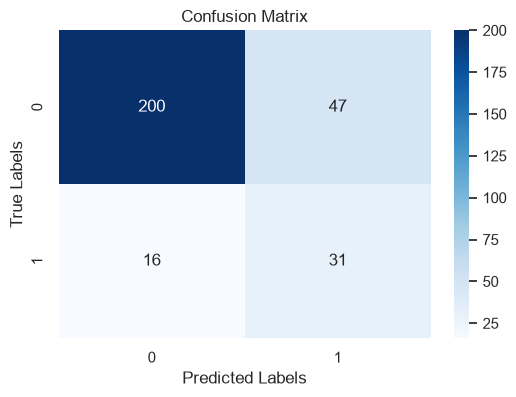

In [61]:
accuracy = accuracy_score(y_test, y_pred_xgb_reduced)
print("Accuracy :	",accuracy)

precision = precision_score(y_test, y_pred_xgb_reduced)
print("Precision :	",precision)

recall = recall_score(y_test, y_pred_xgb_reduced)
print("Recall :	",recall)

f1 = f1_score(y_test, y_pred_xgb_reduced)
print("F1-Score :	",f1)

fpr, tpr, thresholds = roc_curve(y_test, XGB_Model_Reduced.predict_proba(X_test_reduced)[:, 1])
auc = roc_auc_score(y_test, y_pred_xgb_reduced)
print("AUC :		",auc)

conf_matrix = confusion_matrix(y_test, y_pred_xgb_reduced)
print("Confusion Matrix :	",conf_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

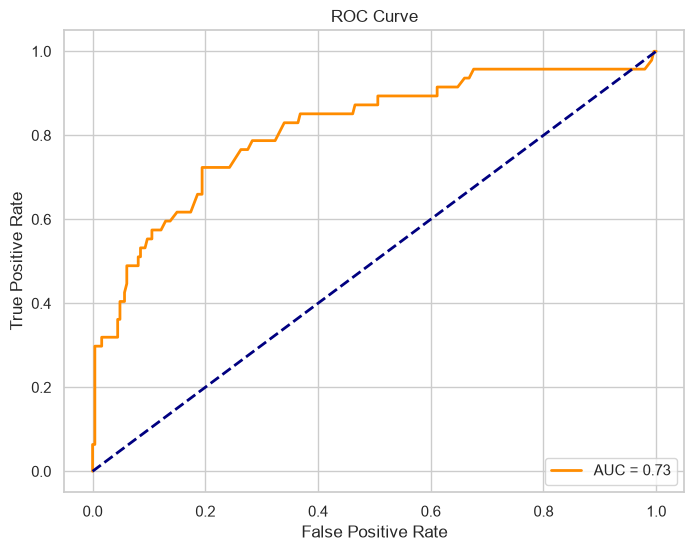

In [62]:
# Visualization of ROC AUC Curve

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [63]:
# ---- Capturing XGBoost (tuned, reduced-feature) metrics for model comparison later ----
# Reuses the bare accuracy/precision/recall/f1/auc/train_acc variables already computed
# above for XGB_Model_Reduced -- no retraining, just aliasing into named variables.
Accuracy_XGB = accuracy
Precision_XGB = precision
Recall_XGB = recall
F1_score_XGB = f1
AUC_XGB = auc
Train_Accuracy_XGB = train_acc
Conf_Matrix_XGB = conf_matrix

print("Train Accuracy (XGB):", Train_Accuracy_XGB)
print("Test Accuracy (XGB) :", Accuracy_XGB)
print("Precision (XGB)     :", Precision_XGB)
print("Recall (XGB)        :", Recall_XGB)
print("F1 (XGB)             :", F1_score_XGB)
print("AUC (XGB)            :", AUC_XGB)


Train Accuracy (XGB): 0.7950680272108843
Test Accuracy (XGB) : 0.7857142857142857
Precision (XGB)     : 0.3974358974358974
Recall (XGB)        : 0.6595744680851063
F1 (XGB)             : 0.496
AUC (XGB)            : 0.7346455336376948


#### Model 4. Decision Tree model

##### 4.1 Without Hyperparameter Tuning


Evaluation Metrics:
Accuracy :	 0.7959183673469388
Precision :	 0.3617021276595745
Recall :	 0.3617021276595745
F1-Score :	 0.3617021276595745
AUC :		 0.6201223188905159
Confusion Matrix :	 [[217  30]
 [ 30  17]]


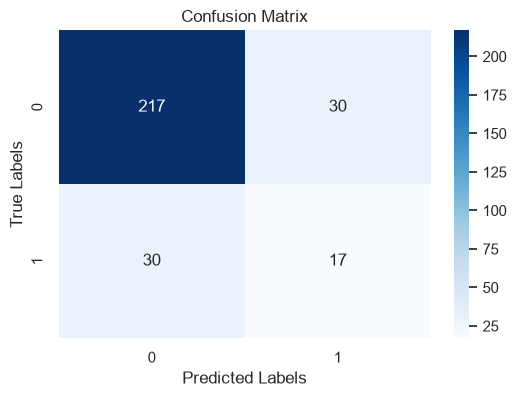

In [64]:


DTModel = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier())
])
DTModel.fit(X_train, y_train)

y_pred_DT = DTModel.predict(X_test)

# Evaluation Metrics
print("\nEvaluation Metrics:")
accuracy = accuracy_score(y_test, y_pred_DT)
print("Accuracy :\t",accuracy)

from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred_DT)
print("Precision :\t",precision)

from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred_DT)
print("Recall :\t",recall)

from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred_DT)
print("F1-Score :\t",f1)

from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, DTModel.predict_proba(X_test)[:, 1])
auc = roc_auc_score(y_test, y_pred_DT)
print("AUC :\t\t",auc)

from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred_DT)
print("Confusion Matrix :\t",conf_matrix)

# Visualization of Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

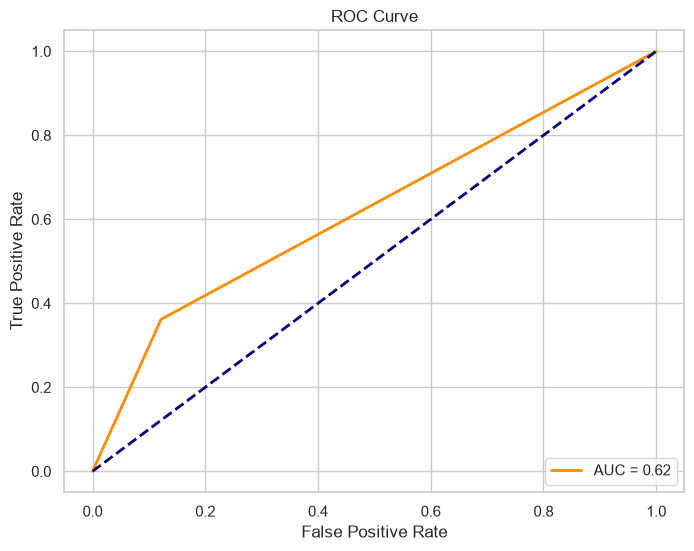

In [65]:
# Visualization of ROC AUC Curve

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

##### 4.2 Decision Tree Hyperparameter Tuning

In [66]:


dt = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    'model__max_depth': [3, 5, 7, 10, 15, None],
    'model__min_samples_leaf': [2, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV Recall  :", grid_dt.best_score_)

best_dt = grid_dt.best_estimator_


Best Parameters: {'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 20, 'model__min_samples_split': 2}
Best CV Recall  : 0.4052631578947369


##### 4.3 Final Metrics using best parameters (Decision Tree)

Training Metrics
----------------
Accuracy: 0.8630952380952381

Testing Metrics
----------------
Accuracy : 0.8231292517006803
Precision: 0.43902439024390244
Recall   : 0.3829787234042553
F1       : 0.4090909090909091
AUC      : 0.6449306572486864
Diff (Train - Test) Accuracy: 0.03996598639455784


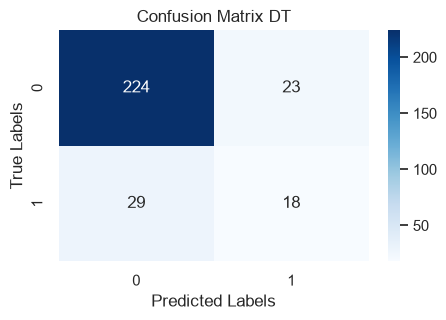

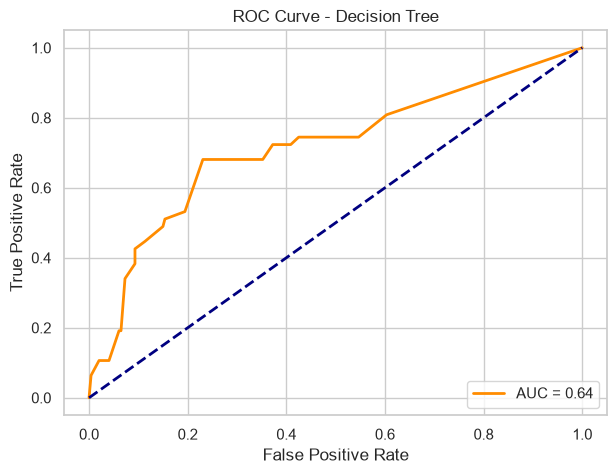

In [67]:
train_pred_DT = best_dt.predict(X_train)
test_pred_DT = best_dt.predict(X_test)

Train_Accuracy_DT = accuracy_score(y_train, train_pred_DT)
Accuracy_DT = accuracy_score(y_test, test_pred_DT)
Precision_DT = precision_score(y_test, test_pred_DT)
Recall_DT = recall_score(y_test, test_pred_DT)
F1_score_DT = f1_score(y_test, test_pred_DT)

fpr_DT, tpr_DT, thresholds = roc_curve(y_test, best_dt.predict_proba(X_test)[:, 1])
AUC_DT = roc_auc_score(y_test, test_pred_DT)
Conf_Matrix_DT = confusion_matrix(y_test, test_pred_DT)

print("Training Metrics")
print("----------------")
print("Accuracy:", Train_Accuracy_DT)

print("\nTesting Metrics")
print("----------------")
print("Accuracy :", Accuracy_DT)
print("Precision:", Precision_DT)
print("Recall   :", Recall_DT)
print("F1       :", F1_score_DT)
print("AUC      :", AUC_DT)
print("Diff (Train - Test) Accuracy:", Train_Accuracy_DT - Accuracy_DT)

# Visualization of Confusion Matrix
plt.figure(figsize=(5, 3))
sns.heatmap(Conf_Matrix_DT, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix DT')
plt.show()

# Visualization of ROC AUC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr_DT, tpr_DT, color='darkorange', lw=2, label=f'AUC = {AUC_DT:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc='lower right')
plt.show()


#### Model 5. KNN

##### 5.1 Without Parameters

In [68]:


KNN = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', KNeighborsClassifier(n_neighbors=5))
])
KNN.fit(X_train, y_train)

y_pred_KNN = KNN.predict(X_test)

y_pred_Train_KNN = KNN.predict(X_train)


In [69]:
# Evaluation Metrics
print("\nEvaluation Metrics:")

print("Training Accuracy:", round(accuracy_score(y_train, y_pred_Train_KNN), 2))

accuracy = accuracy_score(y_test, y_pred_KNN)
print("Accuracy :\t",accuracy)

precision = precision_score(y_test, y_pred_KNN)
print("Precision :\t",precision)

recall = recall_score(y_test, y_pred_KNN)
print("Recall :\t",recall)

f1 = f1_score(y_test, y_pred_KNN)
print("F1-Score :\t",f1)

fpr, tpr, thresholds = roc_curve(y_test, KNN.predict_proba(X_test)[:, 1])
auc = roc_auc_score(y_test, y_pred_KNN)
print("AUC :\t\t",auc)


conf_matrix = confusion_matrix(y_test, y_pred_KNN)
print("Confusion Matrix :\t",conf_matrix)




Evaluation Metrics:
Training Accuracy: 0.78
Accuracy :	 0.6156462585034014
Precision :	 0.21551724137931033
Recall :	 0.5319148936170213
F1-Score :	 0.3067484662576687
AUC :		 0.5817469204927211
Confusion Matrix :	 [[156  91]
 [ 22  25]]


##### 5.2 Hypertuning 

In [70]:


knn = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', KNeighborsClassifier())
])

param_grid = {
    'model__n_neighbors': [5, 7, 9, 11, 13, 15],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print("Best CV recall:", grid_knn.best_score_)

best_KNN = grid_knn.best_estimator_
print(best_KNN)

y_pred = best_KNN.predict(X_test)

print(classification_report(y_test, y_pred))


Best CV recall: 0.7421052631578947
Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('model',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=15))])
              precision    recall  f1-score   support

           0       0.88      0.55      0.68       247
           1       0.21      0.62      0.31        47

    accuracy                           0.56       294
   macro avg       0.54      0.58      0.49       294
weighted avg       0.77      0.56      0.62       294



##### 5.3 Final Metrics using best parameters (KNN)

Training Metrics
----------------
Accuracy: 0.6700680272108843

Testing Metrics
----------------
Accuracy : 0.5578231292517006
Precision: 0.20567375886524822
Recall   : 0.6170212765957447
F1       : 0.30851063829787234
AUC      : 0.5817899905245929
Diff (Train - Test) Accuracy: 0.11224489795918369


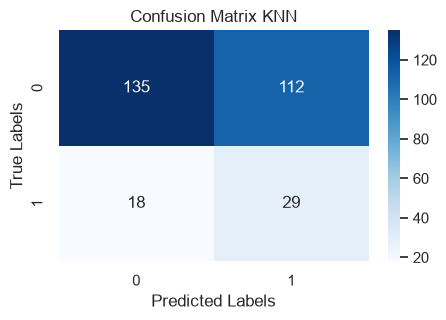

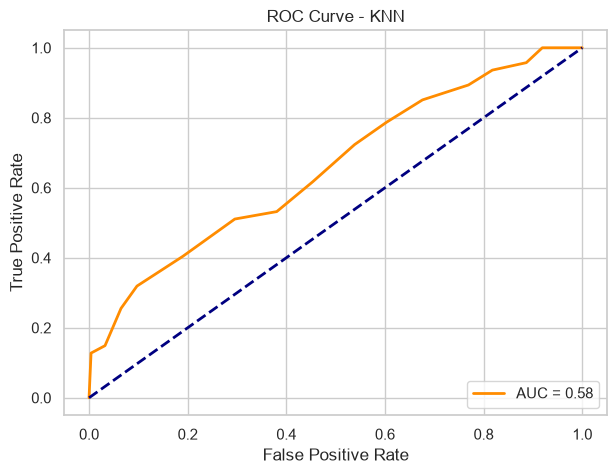

In [71]:
train_pred_KNN = best_KNN.predict(X_train)
test_pred_KNN = best_KNN.predict(X_test)

Train_Accuracy_KNN = accuracy_score(y_train, train_pred_KNN)
Accuracy_KNN = accuracy_score(y_test, test_pred_KNN)
Precision_KNN = precision_score(y_test, test_pred_KNN)
Recall_KNN = recall_score(y_test, test_pred_KNN)
F1_score_KNN = f1_score(y_test, test_pred_KNN)

fpr_KNN, tpr_KNN, thresholds = roc_curve(y_test, best_KNN.predict_proba(X_test)[:, 1])
AUC_KNN = roc_auc_score(y_test, test_pred_KNN)
Conf_Matrix_KNN = confusion_matrix(y_test, test_pred_KNN)

print("Training Metrics")
print("----------------")
print("Accuracy:", Train_Accuracy_KNN)

print("\nTesting Metrics")
print("----------------")
print("Accuracy :", Accuracy_KNN)
print("Precision:", Precision_KNN)
print("Recall   :", Recall_KNN)
print("F1       :", F1_score_KNN)
print("AUC      :", AUC_KNN)
print("Diff (Train - Test) Accuracy:", Train_Accuracy_KNN - Accuracy_KNN)

# Visualization of Confusion Matrix
plt.figure(figsize=(5, 3))
sns.heatmap(Conf_Matrix_KNN, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix KNN')
plt.show()

# Visualization of ROC AUC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr_KNN, tpr_KNN, color='darkorange', lw=2, label=f'AUC = {AUC_KNN:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend(loc='lower right')
plt.show()


#### Model 6. LightGBM

##### 6.1 Hyperparameter Tuning

In [72]:

lgbm = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(random_state=42, verbose=-1))
])

param_grid_lgbm = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [3, 5, 7, -1],
    'model__num_leaves': [15, 31, 63]
}

grid_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid_lgbm,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_lgbm.fit(X_train, y_train)

print("Best Parameters:", grid_lgbm.best_params_)
print("Best CV Recall  :", grid_lgbm.best_score_)

best_lgbm = grid_lgbm.best_estimator_


Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__num_leaves': 15}
Best CV Recall  : 0.3894736842105263


##### 6.2 Final Metrics using best parameters (LightGBM)

Training Metrics
----------------
Accuracy: 0.9778911564625851

Testing Metrics
----------------
Accuracy : 0.8605442176870748
Precision: 0.6666666666666666
Recall   : 0.2553191489361702
F1       : 0.36923076923076925
AUC      : 0.6155138254802308
Diff (Train - Test) Accuracy: 0.11734693877551028


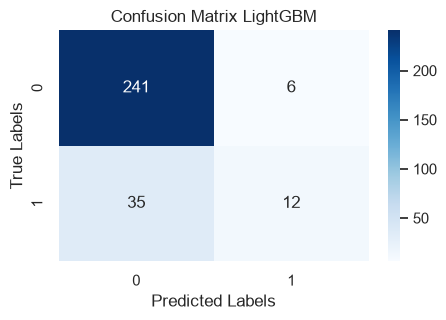

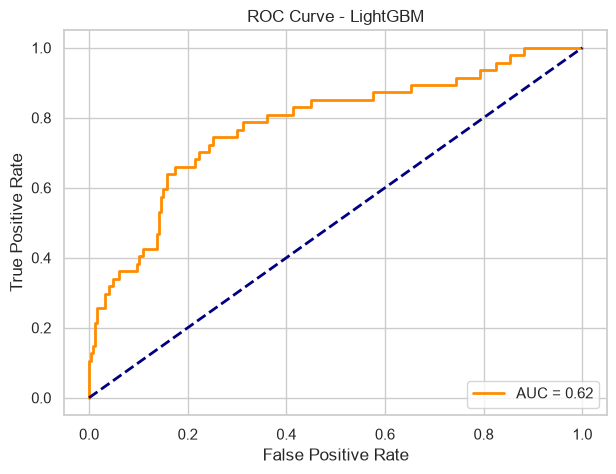

In [73]:
train_pred_LGBM = best_lgbm.predict(X_train)
test_pred_LGBM = best_lgbm.predict(X_test)

Train_Accuracy_LGBM = accuracy_score(y_train, train_pred_LGBM)
Accuracy_LGBM = accuracy_score(y_test, test_pred_LGBM)
Precision_LGBM = precision_score(y_test, test_pred_LGBM)
Recall_LGBM = recall_score(y_test, test_pred_LGBM)
F1_score_LGBM = f1_score(y_test, test_pred_LGBM)

fpr_LGBM, tpr_LGBM, thresholds = roc_curve(y_test, best_lgbm.predict_proba(X_test)[:, 1])
AUC_LGBM = roc_auc_score(y_test, test_pred_LGBM)
Conf_Matrix_LGBM = confusion_matrix(y_test, test_pred_LGBM)

print("Training Metrics")
print("----------------")
print("Accuracy:", Train_Accuracy_LGBM)

print("\nTesting Metrics")
print("----------------")
print("Accuracy :", Accuracy_LGBM)
print("Precision:", Precision_LGBM)
print("Recall   :", Recall_LGBM)
print("F1       :", F1_score_LGBM)
print("AUC      :", AUC_LGBM)
print("Diff (Train - Test) Accuracy:", Train_Accuracy_LGBM - Accuracy_LGBM)

# Visualization of Confusion Matrix
plt.figure(figsize=(5, 3))
sns.heatmap(Conf_Matrix_LGBM, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix LightGBM')
plt.show()

# Visualization of ROC AUC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr_LGBM, tpr_LGBM, color='darkorange', lw=2, label=f'AUC = {AUC_LGBM:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM')
plt.legend(loc='lower right')
plt.show()


#### Model 7. MLP (Neural Network)

##### 7.1 Hyperparameter Tuning

In [74]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', MLPClassifier(
        random_state=42,
        max_iter=1000,
        early_stopping=True,
        n_iter_no_change=15
    ))
])

param_grid_mlp = {
    'model__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': [0.0001, 0.001, 0.01],
    # 'learning_rate_init': [0.001, 0.01]
}

grid_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_mlp.fit(X_train, y_train)

print("Best Parameters:", grid_mlp.best_params_)
print("Best CV Recall  :", grid_mlp.best_score_)

best_mlp = grid_mlp.best_estimator_


Best Parameters: {'model__activation': 'tanh', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (100,)}
Best CV Recall  : 0.6736842105263158


Training Metrics
----------------
Accuracy: 0.7602040816326531

Testing Metrics
----------------
Accuracy : 0.7448979591836735
Precision: 0.35106382978723405
Recall   : 0.7021276595744681
F1       : 0.46808510638297873
AUC      : 0.7275820484107158
Diff (Train - Test) Accuracy: 0.015306122448979553


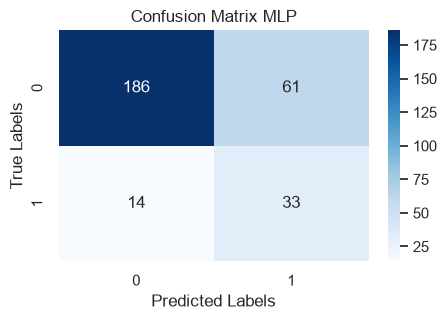

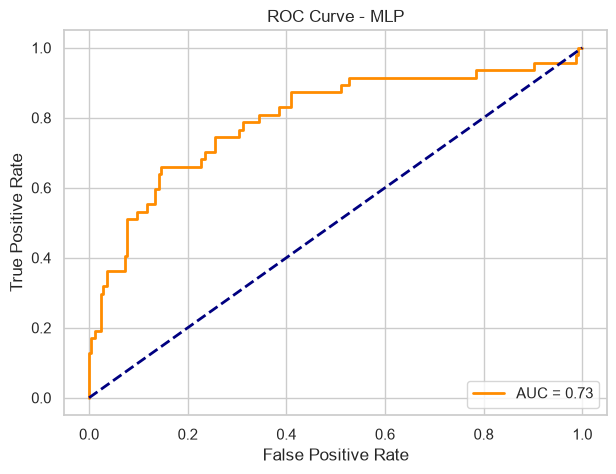

In [75]:
train_pred_MLP = best_mlp.predict(X_train)
test_pred_MLP = best_mlp.predict(X_test)

Train_Accuracy_MLP = accuracy_score(y_train, train_pred_MLP)
Accuracy_MLP = accuracy_score(y_test, test_pred_MLP)
Precision_MLP = precision_score(y_test, test_pred_MLP)
Recall_MLP = recall_score(y_test, test_pred_MLP)
F1_score_MLP = f1_score(y_test, test_pred_MLP)

fpr_MLP, tpr_MLP, thresholds = roc_curve(y_test, best_mlp.predict_proba(X_test)[:, 1])
AUC_MLP = roc_auc_score(y_test, test_pred_MLP)
Conf_Matrix_MLP = confusion_matrix(y_test, test_pred_MLP)

print("Training Metrics")
print("----------------")
print("Accuracy:", Train_Accuracy_MLP)

print("\nTesting Metrics")
print("----------------")
print("Accuracy :", Accuracy_MLP)
print("Precision:", Precision_MLP)
print("Recall   :", Recall_MLP)
print("F1       :", F1_score_MLP)
print("AUC      :", AUC_MLP)
print("Diff (Train - Test) Accuracy:", Train_Accuracy_MLP - Accuracy_MLP)

# Visualization of Confusion Matrix
plt.figure(figsize=(5, 3))
sns.heatmap(Conf_Matrix_MLP, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix MLP')
plt.show()

# Visualization of ROC AUC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr_MLP, tpr_MLP, color='darkorange', lw=2, label=f'AUC = {AUC_MLP:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - MLP')
plt.legend(loc='lower right')
plt.show()


### 5. Model Comparison (Hyper-tuned Models)

In [76]:
model_comparison = {
    'Logistic Regression': {
        'Train_Accuracy': Train_Accuracy_LR,
        'Test_Accuracy': Accuracy_LR,
        'Precision': Precision_LR,
        'Recall': Recall_LR,
        'F1_Score': F1_score_LR,
        'ROC_AUC': AUC_LR,
    },
    'Random Forest': {
        'Train_Accuracy': Train_Accuracy_RF,
        'Test_Accuracy': Accuracy_RF,
        'Precision': Precision_RF,
        'Recall': Recall_RF,
        'F1_Score': F1_score_RF,
        'ROC_AUC': AUC_RF,
    },
    'XGBoost': {
        'Test_Accuracy': Accuracy_XGB_full,
        'Precision': Precision_XGB_full,
        'Recall': Recall_XGB_full,
        'F1_Score': F1_score_XGB_full,
    },
    'XGBoost (reduced)': {
        'Train_Accuracy': Train_Accuracy_XGB,
        'Test_Accuracy': Accuracy_XGB,
        'Precision': Precision_XGB,
        'Recall': Recall_XGB,
        'F1_Score': F1_score_XGB,
        'ROC_AUC': AUC_XGB,
    },
    'Decision Tree': {
        'Train_Accuracy': Train_Accuracy_DT,
        'Test_Accuracy': Accuracy_DT,
        'Precision': Precision_DT,
        'Recall': Recall_DT,
        'F1_Score': F1_score_DT,
        'ROC_AUC': AUC_DT,
    },
    'KNN': {
        'Train_Accuracy': Train_Accuracy_KNN,
        'Test_Accuracy': Accuracy_KNN,
        'Precision': Precision_KNN,
        'Recall': Recall_KNN,
        'F1_Score': F1_score_KNN,
        'ROC_AUC': AUC_KNN,
    },
    'LightGBM': {
        'Train_Accuracy': Train_Accuracy_LGBM,
        'Test_Accuracy': Accuracy_LGBM,
        'Precision': Precision_LGBM,
        'Recall': Recall_LGBM,
        'F1_Score': F1_score_LGBM,
        'ROC_AUC': AUC_LGBM,
    },
    'MLP': {
        'Train_Accuracy': Train_Accuracy_MLP,
        'Test_Accuracy': Accuracy_MLP,
        'Precision': Precision_MLP,
        'Recall': Recall_MLP,
        'F1_Score': F1_score_MLP,
        'ROC_AUC': AUC_MLP,
    },
}

comparison_df = pd.DataFrame(model_comparison).T.round(4)
comparison_df = comparison_df.sort_values(by='Recall', ascending=False)
comparison_df


,Train_Accuracy,Test_Accuracy,Precision,Recall,F1_Score,ROC_AUC
Logistic Regression,0.6446,0.6156,0.2643,0.7872,0.3957,0.6851
MLP,0.7602,0.7449,0.3511,0.7021,0.4681,0.7276
XGBoost (reduced),0.7951,0.7857,0.3974,0.6596,0.4960,0.7346
KNN,0.6701,0.5578,0.2057,0.6170,0.3085,0.5818
XGBoost,NaN,0.8469,0.5200,0.5532,0.5361,NaN
Random Forest,0.8699,0.8231,0.4444,0.4255,0.4348,0.6622
Decision Tree,0.8631,0.8231,0.4390,0.3830,0.4091,0.6449
LightGBM,0.9779,0.8605,0.6667,0.2553,0.3692,0.6155


##### 5.1 Train vs Test Accuracy (Overfit Check)

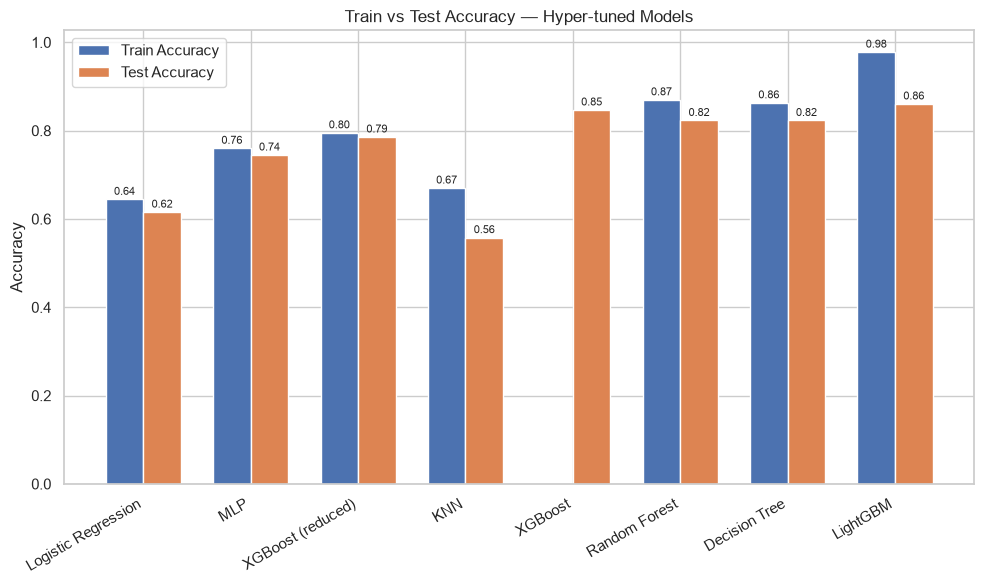

In [77]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Train_Accuracy'], width, label='Train Accuracy', color='#4C72B0')
ax.bar(x + width/2, comparison_df['Test_Accuracy'], width, label='Test Accuracy', color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy \u2014 Hyper-tuned Models')
ax.legend()

for i, v in enumerate(comparison_df['Train_Accuracy']):
    ax.text(i - width/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
for i, v in enumerate(comparison_df['Test_Accuracy']):
    ax.text(i + width/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


##### 5.2 Test F1, Recall & ROC-AUC

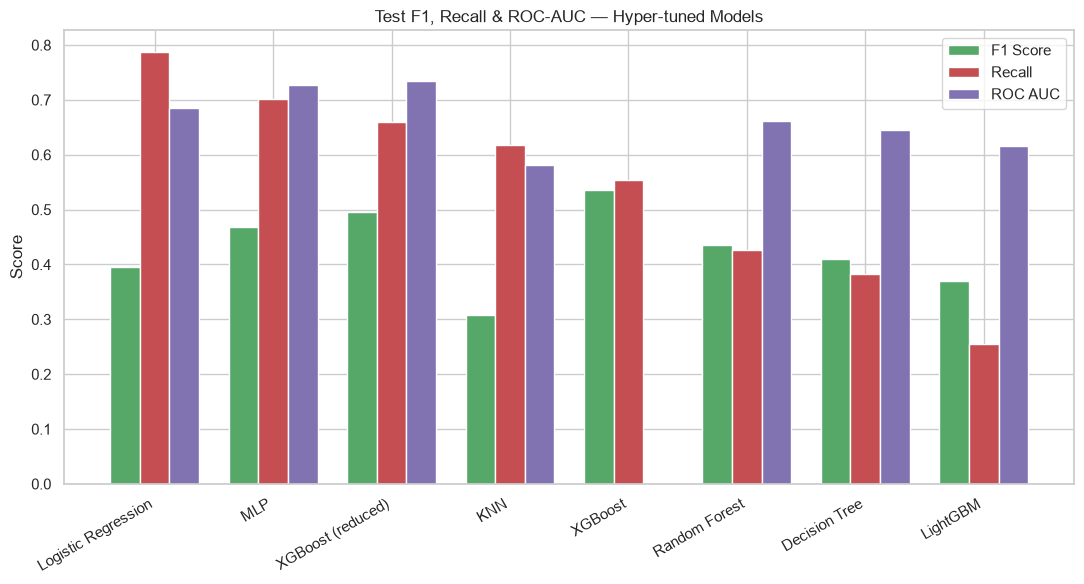

In [78]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df['F1_Score'], width, label='F1 Score', color='#55A868')
ax.bar(x, comparison_df['Recall'], width, label='Recall', color='#C44E52')
ax.bar(x + width, comparison_df['ROC_AUC'], width, label='ROC AUC', color='#8172B2')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('Test F1, Recall & ROC-AUC \u2014 Hyper-tuned Models')
ax.legend()

plt.tight_layout()
plt.show()


##### 5.3 Test F1, Recall & Precision

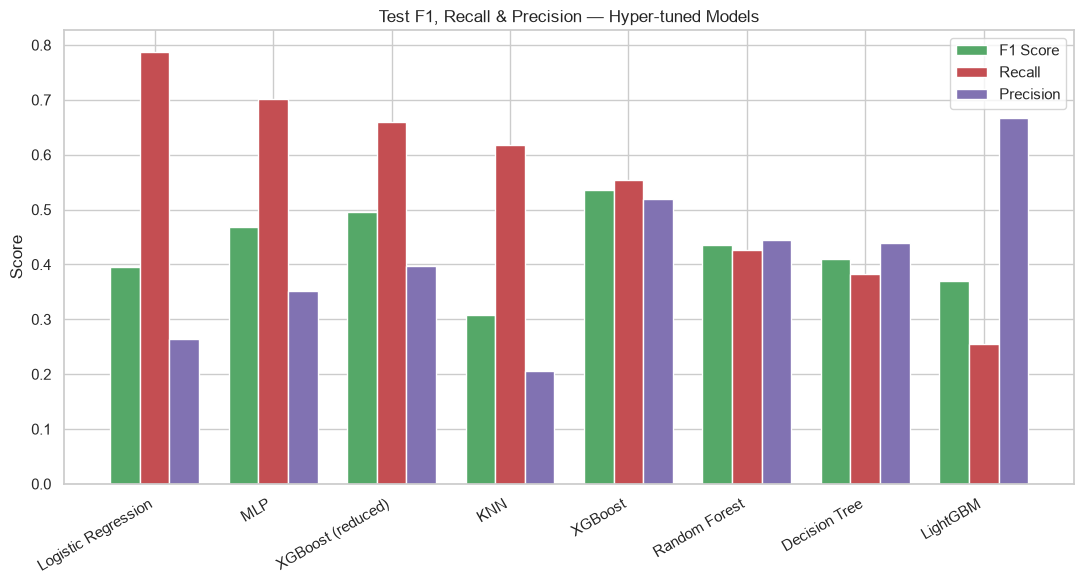

In [79]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df['F1_Score'], width, label='F1 Score', color='#55A868')
ax.bar(x, comparison_df['Recall'], width, label='Recall', color='#C44E52')
ax.bar(x + width, comparison_df['Precision'], width, label='Precision', color='#8172B2')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('Test F1, Recall & Precision \u2014 Hyper-tuned Models')
ax.legend()

plt.tight_layout()
plt.show()


### 6. SHAP: Explaining the Best Model

##### 6.1 Top features of LR Model using Shap

In [80]:
X_train_shap = best_lr_model.named_steps['scaler'].transform(X_train) ##best_lr_model is  Logistic regression
X_test_shap = best_lr_model.named_steps['scaler'].transform(X_test)
explainer = shap.Explainer(best_lr_model.named_steps['model'], X_train_shap)
shap_values = explainer(X_test_shap)    

Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.


In [81]:
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_shap, columns=feature_names)
X_train_df.columns

Index(['cat__BusinessTravel_Travel_Frequently',
       'cat__BusinessTravel_Travel_Rarely',
       'cat__Department_Research & Development', 'cat__Department_Sales',
       'cat__EducationField_Life Sciences', 'cat__EducationField_Marketing',
       'cat__EducationField_Medical', 'cat__EducationField_Other',
       'cat__EducationField_Technical Degree', 'cat__Gender_Male',
       'cat__JobRole_Human Resources', 'cat__JobRole_Laboratory Technician',
       'cat__JobRole_Manager', 'cat__JobRole_Manufacturing Director',
       'cat__JobRole_Research Director', 'cat__JobRole_Research Scientist',
       'cat__JobRole_Sales Executive', 'cat__JobRole_Sales Representative',
       'cat__MaritalStatus_Married', 'cat__MaritalStatus_Single',
       'cat__OverTime_Yes', 'remainder__Age', 'remainder__DailyRate',
       'remainder__DistanceFromHome', 'remainder__Education',
       'remainder__EnvironmentSatisfaction', 'remainder__HourlyRate',
       'remainder__JobInvolvement', 'remainder__JobLevel

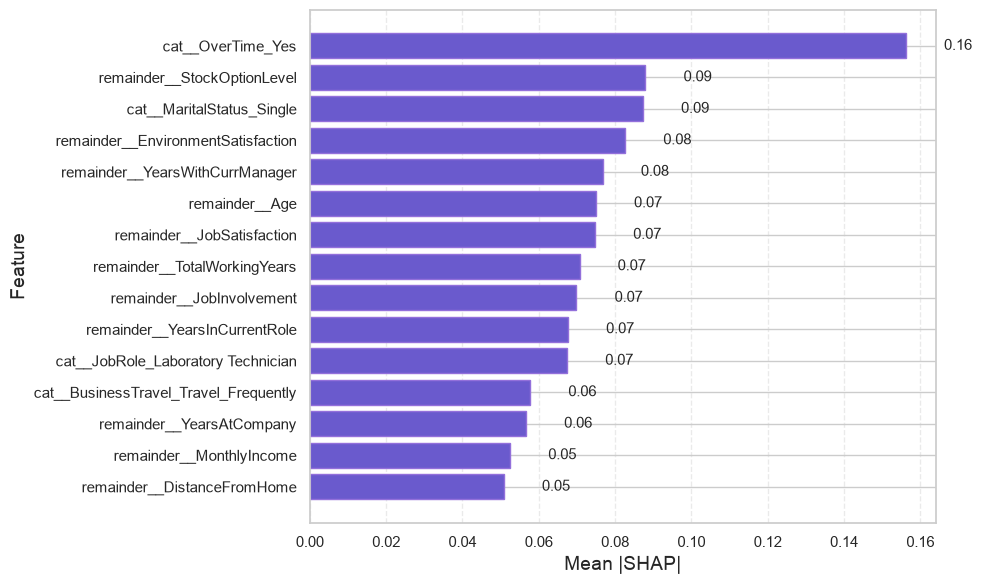

In [82]:


# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_train_df.columns,
    "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)
})

# Sort in decreasing order
feature_importance = feature_importance.sort_values(
    by="Mean |SHAP|",
    ascending=False
)

top_n = 15

top_features = feature_importance.head(top_n)

# Plot
plt.figure(figsize=(10,6))

bars = plt.barh(
    top_features["Feature"],
    top_features["Mean |SHAP|"],
    color="slateblue",
    edgecolor="mediumpurple"
)

# Highest importance at top
plt.gca().invert_yaxis()

plt.xlabel("Mean |SHAP|", fontsize=14)
plt.ylabel("Feature", fontsize=14)

# Add values on bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va='center',
        fontsize=11
    )

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

##### 6.2 Top features of MLP Model using Shap

In [83]:
X_train_shap = best_mlp.named_steps['scaler'].transform(X_train)
X_test_shap = best_mlp.named_steps['scaler'].transform(X_test)
predict_fn = lambda x: best_mlp.named_steps['model'].predict_proba(x)[:, 1]
explainer = shap.Explainer(predict_fn, X_train_shap)
shap_values = explainer(X_test_shap)

Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.


In [84]:
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_shap, columns=feature_names)
X_train_df.columns

Index(['cat__BusinessTravel_Travel_Frequently',
       'cat__BusinessTravel_Travel_Rarely',
       'cat__Department_Research & Development', 'cat__Department_Sales',
       'cat__EducationField_Life Sciences', 'cat__EducationField_Marketing',
       'cat__EducationField_Medical', 'cat__EducationField_Other',
       'cat__EducationField_Technical Degree', 'cat__Gender_Male',
       'cat__JobRole_Human Resources', 'cat__JobRole_Laboratory Technician',
       'cat__JobRole_Manager', 'cat__JobRole_Manufacturing Director',
       'cat__JobRole_Research Director', 'cat__JobRole_Research Scientist',
       'cat__JobRole_Sales Executive', 'cat__JobRole_Sales Representative',
       'cat__MaritalStatus_Married', 'cat__MaritalStatus_Single',
       'cat__OverTime_Yes', 'remainder__Age', 'remainder__DailyRate',
       'remainder__DistanceFromHome', 'remainder__Education',
       'remainder__EnvironmentSatisfaction', 'remainder__HourlyRate',
       'remainder__JobInvolvement', 'remainder__JobLevel

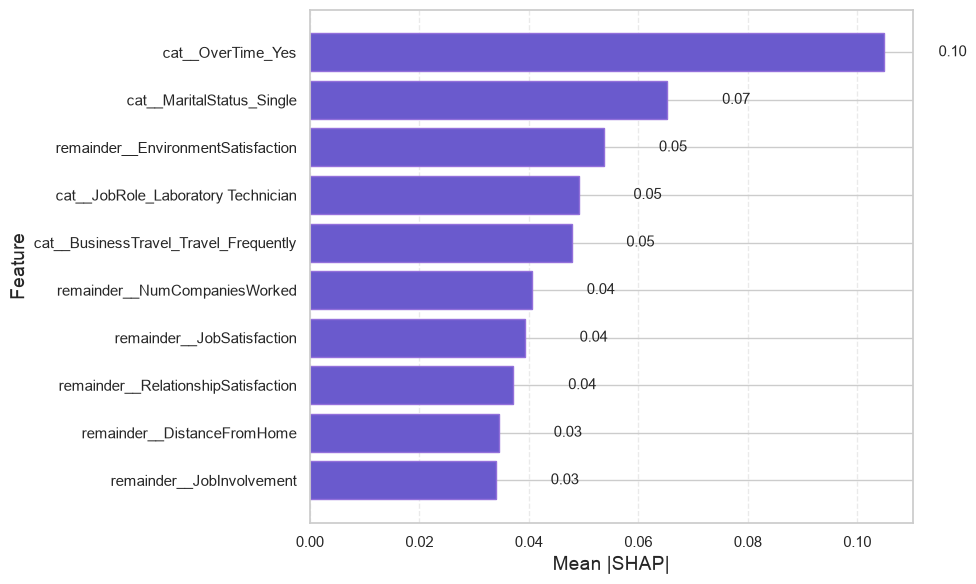

In [89]:


# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_train_df.columns,
    "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)
})

# Sort in decreasing order
feature_importance = feature_importance.sort_values(
    by="Mean |SHAP|",
    ascending=False
)

top_n = 10

top_features = feature_importance.head(top_n)

# Plot
plt.figure(figsize=(10,6))

bars = plt.barh(
    top_features["Feature"],
    top_features["Mean |SHAP|"],
    color="slateblue",
    edgecolor="mediumpurple"
)

# Highest importance at top
plt.gca().invert_yaxis()

plt.xlabel("Mean |SHAP|", fontsize=14)
plt.ylabel("Feature", fontsize=14)

# Add values on bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va='center',
        fontsize=11
    )

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

##### 6.3 Summary plot

Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.


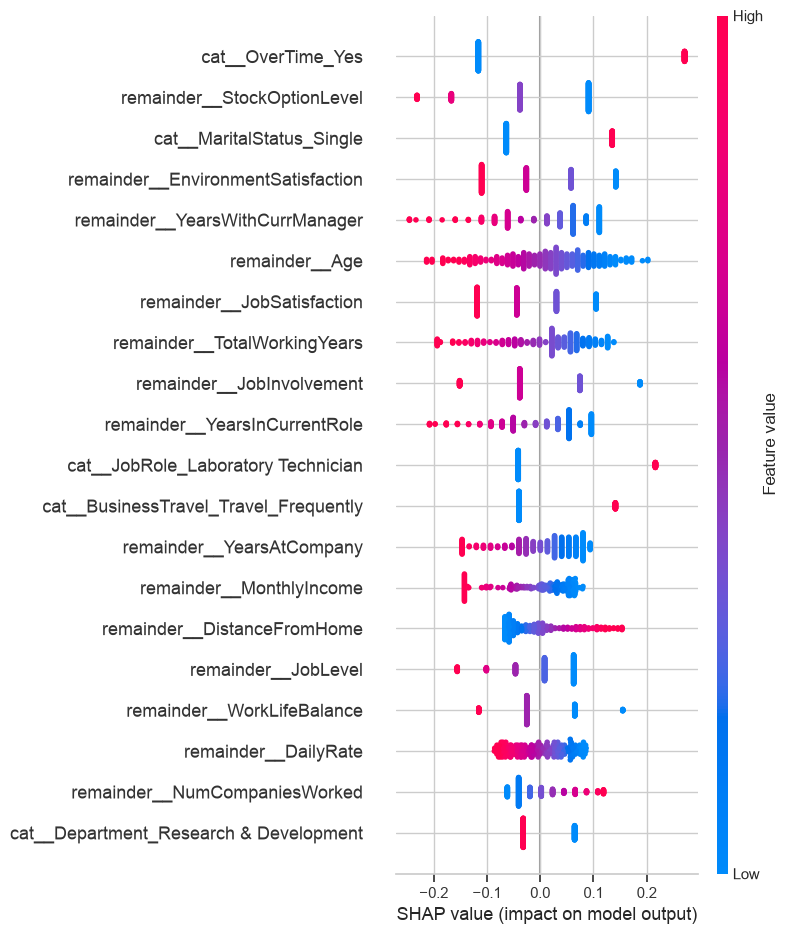

In [101]:
feature_names = preprocessor.get_feature_names_out()

X_train_shap = best_lr_model.named_steps['scaler'].transform(X_train)
X_test_shap = best_lr_model.named_steps['scaler'].transform(X_test)

# wrap in DataFrames with real column names BEFORE creating the explainer
X_train_shap_df = pd.DataFrame(X_train_shap, columns=feature_names)
X_test_shap_df = pd.DataFrame(X_test_shap, columns=feature_names)

explainer = shap.Explainer(best_lr_model.named_steps['model'], X_train_shap_df)
shap_values = explainer(X_test_shap_df)

shap.summary_plot(shap_values, X_test_shap_df, show=True)

 ### 7. Loss Curve Visualized for Iterative Algorithms

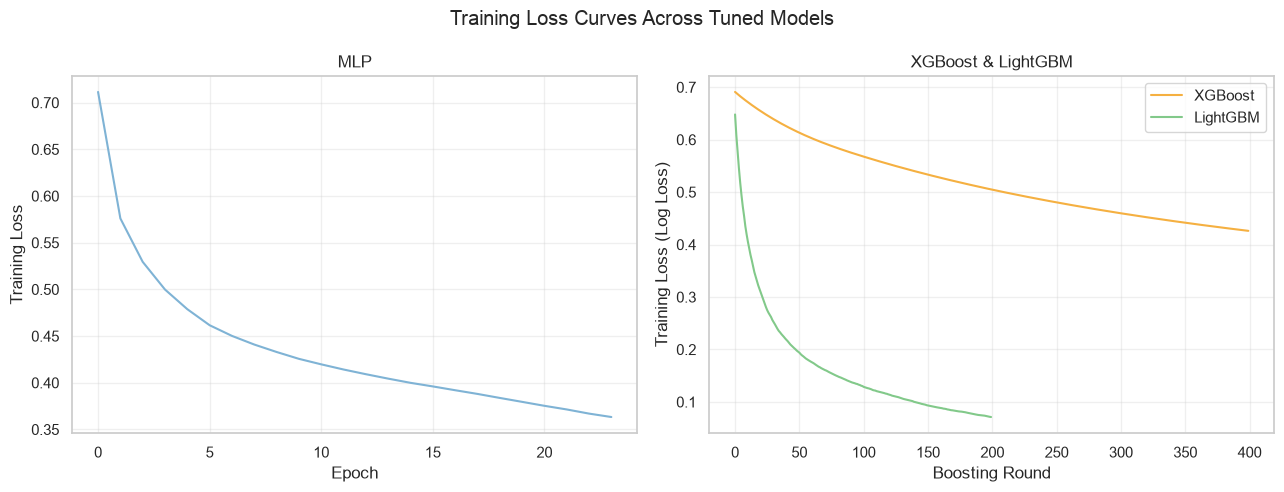

In [102]:
# MLP
mlp_loss = best_mlp.named_steps['model'].loss_curve_

# XGBoost
best_params_xgb = {
    k.replace('model__', ''): v
    for k, v in grid_xgb_full.best_params_.items()
}

# Reproduce the same SMOTE-resampled training data the pipeline used internally
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Refit just the XGBClassifier
xgb_final = xgb.XGBClassifier(
    **best_params_xgb,
    random_state=42,
    eval_metric='logloss',
    n_jobs=1
)
xgb_final.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_train_resampled, y_train_resampled)],
    verbose=False
)
xgb_loss = xgb_final.evals_result()['validation_0']['logloss']

# LightGBM — same pattern
best_params_lgbm = {
    k.replace('model__', ''): v
    for k, v in grid_lgbm.best_params_.items()  # grid_lgbm = your GridSearchCV object for LightGBM
}

lgbm_final = LGBMClassifier(
    **best_params_lgbm,
    random_state=42
)
lgbm_final.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_train_resampled, y_train_resampled)],
    eval_metric='binary_logloss'
)
lgbm_loss = lgbm_final.evals_result_['training']['binary_logloss']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: MLP
axes[0].plot(mlp_loss, color='#7fb3d5')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("MLP")
axes[0].grid(alpha=0.3)

# Right: XGBoost + LightGBM
axes[1].plot(xgb_loss, label="XGBoost", color='#f5b041')
axes[1].plot(lgbm_loss, label="LightGBM", color='#82c98a')
axes[1].set_xlabel("Boosting Round")
axes[1].set_ylabel("Training Loss (Log Loss)")
axes[1].set_title("XGBoost & LightGBM")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Training Loss Curves Across Tuned Models")
plt.tight_layout()
plt.show()